<a href="https://colab.research.google.com/github/dashsumit/Projects/blob/main/V8_of_Full_Dataset_Monolingual_Bengali_News_Dataset_NLP_ML_Approach_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Extractive Summerization


##Importing Necessary Libraries

In [ ]:
!pip install bnlp-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 65.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of bnlp-toolkit to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.4/175.4 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.0 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.7.0-py3-none-any.whl size=171031 sha256=6b0704fc0b32a7a78ad93fa8f646d0311cb809d5e2c978bb16ef0db64b751815
  Stored in directory: /root/.cache/pip/wheels/e0/8c/e0/294d2e4ea0e55792bfc99b6b263e4a0511443da7b69af67688
Successfully built emoj

In [ ]:
!pip install fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.2-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.2-py3-none-any.whl (310 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4647416 sha256=767b400e5de68e80e65908a84bd07369314437b6b9265bca86ba97df3146fd77
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from bnlp import SentencepieceTokenizer
from bnlp import BasicTokenizer # ['আমি', 'বাংলায়', 'গান', 'গাই', '।']
from bnlp import NLTKTokenizer
from bnlp import BengaliCorpus as corpus
from bnlp import BengaliPOS
from collections import Counter
from bnlp import NLTKTokenizer
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from heapq import nlargest,nsmallest
from bnlp.embedding.fasttext import BengaliFasttext
import matplotlib.font_manager as fm## for bengali fonts


In [ ]:
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet,LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.tree import DecisionTreeClassifier,plot_tree
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.naive_bayes import CategoricalNB #categorical handle discrete value like (color,level etc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report,mean_squared_error
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from matplotlib.pyplot import figure
from sklearn.svm import SVC
from sklearn.svm import SVR
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.multioutput import MultiOutputClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print(corpus.stopwords)
print(corpus.punctuations)
print(corpus.letters)
print(corpus.digits)
print(corpus.vowels)

['অতএব', 'অথচ', 'অথবা', 'অনুযায়ী', 'অনেক', 'অনেকে', 'অনেকেই', 'অন্তত', 'অন্য', 'অবধি', 'অবশ্য', 'অর্থাত', 'আই', 'আগামী', 'আগে', 'আগেই', 'আছে', 'আজ', 'আদ্যভাগে', 'আপনার', 'আপনি', 'আবার', 'আমরা', 'আমাকে', 'আমাদের', 'আমার', 'আমি', 'আর', 'আরও', 'ই', 'ইত্যাদি', 'ইহা', 'উচিত', 'উত্তর', 'উনি', 'উপর', 'উপরে', 'এ', 'এঁদের', 'এঁরা', 'এই', 'একই', 'একটি', 'একবার', 'একে', 'এক্', 'এখন', 'এখনও', 'এখানে', 'এখানেই', 'এটা', 'এটাই', 'এটি', 'এত', 'এতটাই', 'এতে', 'এদের', 'এব', 'এবং', 'এবার', 'এমন', 'এমনকী', 'এমনি', 'এর', 'এরা', 'এল', 'এস', 'এসে', 'ঐ', 'ও', 'ওঁদের', 'ওঁর', 'ওঁরা', 'ওই', 'ওকে', 'ওখানে', 'ওদের', 'ওর', 'ওরা', 'কখনও', 'কত', 'কবে', 'কমনে', 'কয়েক', 'কয়েকটি', 'করছে', 'করছেন', 'করতে', 'করবে', 'করবেন', 'করলে', 'করলেন', 'করা', 'করাই', 'করায়', 'করার', 'করি', 'করিতে', 'করিয়া', 'করিয়ে', 'করে', 'করেই', 'করেছিলেন', 'করেছে', 'করেছেন', 'করেন', 'কাউকে', 'কাছ', 'কাছে', 'কাজ', 'কাজে', 'কারও', 'কারণ', 'কি', 'কিংবা', 'কিছু', 'কিছুই', 'কিন্তু', 'কী', 'কে', 'কেউ', 'কেউই', 'কেখা', 'কেন', 'কোটি', 'কোন', 'কোনও'

##Loading CSV File


In [ ]:
df = pd.read_csv('/content/Copy of Monolingual_Bengali_Datasets - Sheet1 (1).csv')
df.sample(5)

,Text,Domain,Sub-Domain
1908,পাঁচ বছরের ব্যবধানে প্রাথমিক ও গণশিক্ষামন্ত্রী...,কৃষি,বাজার ও পণ্য
3698,গত কয়েক মাসে বাংলাদেশ ক্রিকেট নানা চড়াই-উতরা...,খেলাধুলা,ক্রিকেট
3743,৭০ বছরে পা দিয়েছেন তেলেগু সিনেমার কিংবদন্তি অভ...,বিনোদন,বিখ্যাত ব্যক্তি
2196,কিলিয়ান এমবাপ্পের জোড়া গোলে আগের দিন ভিয়ারিয়াল...,খেলাধুলা,ফুটবল
6168,৩০ হাজার কোটি টাকা ব্যয়ে নির্মিত পদ্মা সেতু থে...,ব্যবসা,অর্থনীতি


In [ ]:
df['Sub-Domain'] = df['Sub-Domain'].str.strip()
print("Cleaned 'Sub-Domain' column by stripping whitespace.")
print(df['Sub-Domain'].value_counts().to_markdown())

Cleaned 'Sub-Domain' column by stripping whitespace.
| Sub-Domain                  |   count |
|:----------------------------|--------:|
| সিনেমা                      |     851 |
| নীতি ও প্রশাসন               |     778 |
| সহিংস অপরাধ                  |     693 |
| অর্থসংস্থান ও কোম্পানি           |     644 |
| ক্রিকেট                       |     582 |
| বাজার ও পণ্য                 |     571 |
| ফুটবল                        |     567 |
| বিখ্যাত ব্যক্তি                  |     544 |
| অর্থনীতি                     |     364 |
| ছিনতাই ও সম্পত্তি সংক্রান্ত অপরাধ |     364 |
| সঙ্গীত                        |     357 |
| বাণিজ্য                      |     329 |
| চাষাবাদ ও উদ্ভাবন             |     289 |
| মাদক ও পাচার                |     256 |
| টেনিস                       |      54 |


In [ ]:
len(df)

7243

## Identify Target Variable

### Subtask:
Clarify which column ('Domain' or 'Sub-Domain') you intend to use as the target variable for classification. This will guide the subsequent steps.


**Reasoning**:
Based on common classification task practices, 'Domain' is chosen as the target variable for its broader categorization, which is often a good starting point for text classification. I will store this choice in the `target_variable`.



In [ ]:
target_variable1 = 'Domain'
target_variable2 ='Sub-Domain'
print(f"Target variable chosen: {target_variable1}")
print(f"Target variable chosen: {target_variable2}")

Target variable chosen: Domain
Target variable chosen: Sub-Domain


## Explore and Understand Data

### Subtask:
Analyze the distribution of categories in the chosen target variable and inspect sample texts to understand their characteristics.


**Reasoning**:
To understand the distribution of the target variable, I will display the unique values and their counts. Then, to get a qualitative understanding of the text data, I will print a few sample entries from the 'Text' column along with their corresponding target variable.



In [ ]:
print(f"\nDistribution of '{target_variable1}':")
print(df[target_variable1].value_counts())

print(f"\nSample entries from 'Text' and {target_variable1}:")
# Note: Use the variable name without quotes inside the list
print(df[['Text', target_variable1]].sample(5).to_markdown(index=False))


Distribution of 'Domain':
Domain
কৃষি        1638
ব্যবসা      1337
অপরাধ       1313
খেলাধুলা    1203
বিনোদন      1148
বিনোদন       604
Name: count, dtype: int64

Sample entries from 'Text' and Domain:
| Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [ ]:
target_variable = 'Sub-Domain'
print(f"Corrected target variable chosen: {target_variable}")

print(f"Distribution of '{target_variable}':\n{df[target_variable].value_counts()}\n")

print(f"Sample entries from 'Text' and '{target_variable}':\n")
print(df[['Text', target_variable]].sample(5).to_markdown(index=False))

Corrected target variable chosen: Sub-Domain
Distribution of 'Sub-Domain':
Sub-Domain
সিনেমা                               851
নীতি ও প্রশাসন                       778
সহিংস অপরাধ                          693
অর্থসংস্থান ও কোম্পানি               644
ক্রিকেট                              582
বাজার ও পণ্য                         571
ফুটবল                                567
বিখ্যাত ব্যক্তি                      544
অর্থনীতি                             364
ছিনতাই ও সম্পত্তি সংক্রান্ত অপরাধ    364
সঙ্গীত                               357
বাণিজ্য                              329
চাষাবাদ ও উদ্ভাবন                    289
মাদক ও পাচার                         256
টেনিস                                 54
Name: count, dtype: int64

Sample entries from 'Text' and 'Sub-Domain':

| Text                                                                                                                                                                                                                            

**Reasoning**:
Before proceeding with further preprocessing steps, it's beneficial to observe the initial state of the 'Text' column. This allows for a clear comparison after subsequent cleaning steps, ensuring that the transformations are applied correctly.



In [ ]:
print("Original 'Text' column (first 5 entries):")
print(df['Text'].head(5).to_markdown(index=False))

Original 'Text' column (first 5 entries):
| Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7243 entries, 0 to 7242
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        7242 non-null   object
 1   Domain      7243 non-null   object
 2   Sub-Domain  7243 non-null   object
dtypes: object(3)
memory usage: 169.9+ KB


In [ ]:
df.isnull().sum()

,0
Text,1
Domain,0
Sub-Domain,0


In [ ]:
df.dropna()

,Text,Domain,Sub-Domain
0,ঈদুল আজহা উপলক্ষে আজ প্রেক্ষাগৃহে মুক্তি পাচ্ছ...,বিনোদন,সিনেমা
1,কৃষি ব্যাংকের ৬৩ কোটি টাকা আত্মসাতের মামলায় কৃ...,কৃষি,বাজার ও পণ্য
2,অনলাইনে প্রাণনাশের হুমকি দেওয়ার অভিযোগে রাজধান...,অপরাধ,সহিংস অপরাধ
3,এবার সৌরবিদ্যুতের ব্যবসায় আসছে দেশের শীর্ষস্থা...,কৃষি,বাজার ও পণ্য
4,রাজধানীর কামরাঙ্গীরচরে ৪ বছরের এক মেয়েশিশুকে য...,অপরাধ,সহিংস অপরাধ
...,...,...,...
7238,‘ডিমলাইট’ধরন: সিনেমাস্ট্রিমিং: চরকিদিনক্ষণ: চল...,বিনোদন,সিনেমা
7239,টি-টুয়েন্টি বিশ্বকাপের গ্রুপ পর্বের ম্যাচ সব ম...,খেলাধুলা,ক্রিকেট
7240,ঢাকাসহ সারা দেশে পুলিশের বিশেষ অভিযান ‘অপারেশন...,অপরাধ,মাদক ও পাচার
7241,রাজধানীর মুগদা জেনারেল হাসপাতালের কাছে শান্তা ...,অপরাধ,সহিংস অপরাধ


In [ ]:
df.describe()

,Text,Domain,Sub-Domain
count,7242,7243,7243
unique,7180,6,15
top,বিশ্ববাজারে সদ্য সমাপ্ত সেপ্টেম্বরে খাদ্যপণ্যে...,কৃষি,সিনেমা
freq,2,1638,851


In [ ]:
df['Domain'].value_counts()

,count
Domain,
কৃষি,1638
ব্যবসা,1337
অপরাধ,1313
খেলাধুলা,1203
বিনোদন,1148
বিনোদন,604


In [ ]:
df['Sub-Domain'].str.strip().value_counts()

,count
Sub-Domain,
সিনেমা,851
নীতি ও প্রশাসন,778
সহিংস অপরাধ,693
অর্থসংস্থান ও কোম্পানি,644
ক্রিকেট,582
বাজার ও পণ্য,571
ফুটবল,567
বিখ্যাত ব্যক্তি,544
অর্থনীতি,364


#Bengali Text Preprocessing


##Text Cleaning

In [ ]:
from bnlp import CleanText

clean_text = CleanText(
   fix_unicode=True,
   unicode_norm=True,
   unicode_norm_form="NFKC",
   remove_url=False,
   remove_email=False,
   remove_emoji=False,
   remove_number=False,
   remove_digits=False,
   remove_punct=False,
   replace_with_url="<URL>",
   replace_with_email="<EMAIL>",
   replace_with_number="<NUMBER>",
   replace_with_digit="<DIGIT>",
   replace_with_punct = "<PUNC>"
)

input_text = df['Text']
clean_text = clean_text(input_text)
print(clean_text)

0       ঈদুল আজহা উপলক্ষে আজ প্রেক্ষাগৃহে মুক্তি পাচ্ছ...
1       কৃষি ব্যাংকের ৬৩ কোটি টাকা আত্মসাতের মামলায় কৃ...
2       অনলাইনে প্রাণনাশের হুমকি দেওয়ার অভিযোগে রাজধান...
3       এবার সৌরবিদ্যুতের ব্যবসায় আসছে দেশের শীর্ষস্থা...
4       রাজধানীর কামরাঙ্গীরচরে ৪ বছরের এক মেয়েশিশুকে য...
                              ...                        
7238    'ডিমলাইট'ধরন: সিনেমাস্ট্রিমিং: চরকিদিনক্ষণ: চল...
7239    টি-টুয়েন্টি বিশ্বকাপের গ্রুপ পর্বের ম্যাচ সব ম...
7240    ঢাকাসহ সারা দেশে পুলিশের বিশেষ অভিযান 'অপারেশন...
7241    রাজধানীর মুগদা জেনারেল হাসপাতালের কাছে শান্তা ...
7242    বাজারে দাম নিয়ন্ত্রণ করতে না পেরে ভোক্তা সংরক্...
Name: Text, Length: 7243, dtype: object


##Tokenization(Basic-Tokenization)

In [ ]:
basic_tokenizer = BasicTokenizer()

basic_data= df['Text']
basic_tokens = basic_tokenizer(clean_text)
print(basic_tokens)

['0', 'ঈদুল', 'আজহা', 'উপলক্ষে', 'আজ', 'প্রেক্ষাগৃহে', 'মুক্তি', 'পাচ্ছ...', '1', 'কৃষি', 'ব্যাংকের', '৬৩', 'কোটি', 'টাকা', 'আত্মসাতের', 'মামলায়', 'কৃ...', '2', 'অনলাইনে', 'প্রাণনাশের', 'হুমকি', 'দেওয়ার', 'অভিযোগে', 'রাজধান...', '3', 'এবার', 'সৌরবিদ্যুতের', 'ব্যবসায়', 'আসছে', 'দেশের', 'শীর্ষস্থা...', '4', 'রাজধানীর', 'কামরাঙ্গীরচরে', '৪', 'বছরের', 'এক', 'মেয়েশিশুকে', 'য...', '...', '7238', "'", 'ডিমলাইট', "'", 'ধরন', ':', 'সিনেমাস্ট্রিমিং', ':', 'চরকিদিনক্ষণ', ':', 'চল...', '7239', 'টি', '-', 'টুয়েন্টি', 'বিশ্বকাপের', 'গ্রুপ', 'পর্বের', 'ম্যাচ', 'সব', 'ম...', '7240', 'ঢাকাসহ', 'সারা', 'দেশে', 'পুলিশের', 'বিশেষ', 'অভিযান', "'", 'অপারেশন...', '7241', 'রাজধানীর', 'মুগদা', 'জেনারেল', 'হাসপাতালের', 'কাছে', 'শান্তা', '...', '7242', 'বাজারে', 'দাম', 'নিয়ন্ত্রণ', 'করতে', 'না', 'পেরে', 'ভোক্তা', 'সংরক্...', 'Name', ':', 'Text', ',', 'Length', ':', '7243', ',', 'dtype', ':', 'object']


##Tokenization(NLTK-Tokenization)

In [ ]:
bnltk = NLTKTokenizer()

nltk_text = df['Text'].fillna('') # Fill NaN values with empty string
word_tokens = nltk_text.apply(bnltk.word_tokenize)
sentence_tokens = nltk_text.apply(bnltk.sentence_tokenize)
print(word_tokens)
print(sentence_tokens)

0       [ঈদুল, আজহা, উপলক্ষে, আজ, প্রেক্ষাগৃহে, মুক্তি...
1       [কৃষি, ব্যাংকের, ৬৩, কোটি, টাকা, আত্মসাতের, মা...
2       [অনলাইনে, প্রাণনাশের, হুমকি, দেওয়ার, অভিযোগে, ...
3       [এবার, সৌরবিদ্যুতের, ব্যবসায়, আসছে, দেশের, শীর...
4       [রাজধানীর, কামরাঙ্গীরচরে, ৪, বছরের, এক, মেয়েশি...
                              ...                        
7238    [‘, ডিমলাইট, ’, ধরন, :, সিনেমাস্ট্রিমিং, :, চর...
7239    [টি-টুয়েন্টি, বিশ্বকাপের, গ্রুপ, পর্বের, ম্যাচ...
7240    [ঢাকাসহ, সারা, দেশে, পুলিশের, বিশেষ, অভিযান, ‘...
7241    [রাজধানীর, মুগদা, জেনারেল, হাসপাতালের, কাছে, শ...
7242    [বাজারে, দাম, নিয়ন্ত্রণ, করতে, না, পেরে, ভোক্ত...
Name: Text, Length: 7243, dtype: object
0       [ঈদুল আজহা উপলক্ষে আজ প্রেক্ষাগৃহে মুক্তি পাচ্...
1       [কৃষি ব্যাংকের ৬৩ কোটি টাকা আত্মসাতের মামলায় ক...
2       [অনলাইনে প্রাণনাশের হুমকি দেওয়ার অভিযোগে রাজধা...
3       [এবার সৌরবিদ্যুতের ব্যবসায় আসছে দেশের শীর্ষস্থ...
4       [রাজধানীর কামরাঙ্গীরচরে ৪ বছরের এক মেয়েশিশুকে ...
                              ..

##Removing Stopwards from Tokens

In [ ]:
stopwords_set = set(corpus.stopwords)


def remove_stopwords_efficient(text):
    if isinstance(text, str):
        tokens = text.split()
        filtered_tokens = [word for word in tokens if word not in stopwords_set]
        return ' '.join(filtered_tokens)
    return text

In [ ]:
df['Text'] = df['Text'].apply(remove_stopwords_efficient)
print("Efficiently removed stopwords from 'Text' column (first 5 entries):")
print(df['Text'].sample(5).to_markdown(index=False))

Efficiently removed stopwords from 'Text' column (first 5 entries):
| Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

##Removing Punctuation


In [ ]:
punctuation_set = set(corpus.punctuations)

def remove_punctuations_efficient(text):
    if isinstance(text, str):
        cleaned_tokens = []
        for word in text.split(): # Split into words first
            cleaned_word = ''.join(char for char in word if char not in punctuation_set)
            if cleaned_word: # Only add if not empty after removing punctuation
                cleaned_tokens.append(cleaned_word)
        return ' '.join(cleaned_tokens)
    return text


In [ ]:
df['Text'] = df['Text'].apply(remove_punctuations_efficient)
print("Efficiently removed punctuations from 'Text' column (first 5 entries):")
print(df['Text'].sample(5).to_markdown(index=False))

Efficiently removed punctuations from 'Text' column (first 5 entries):
| Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

#EDA

In [ ]:
font_path = 'Kalpurush.ttf'
prop = fm.FontProperties(fname=font_path)


##Pie Chart(Sub-Domain)

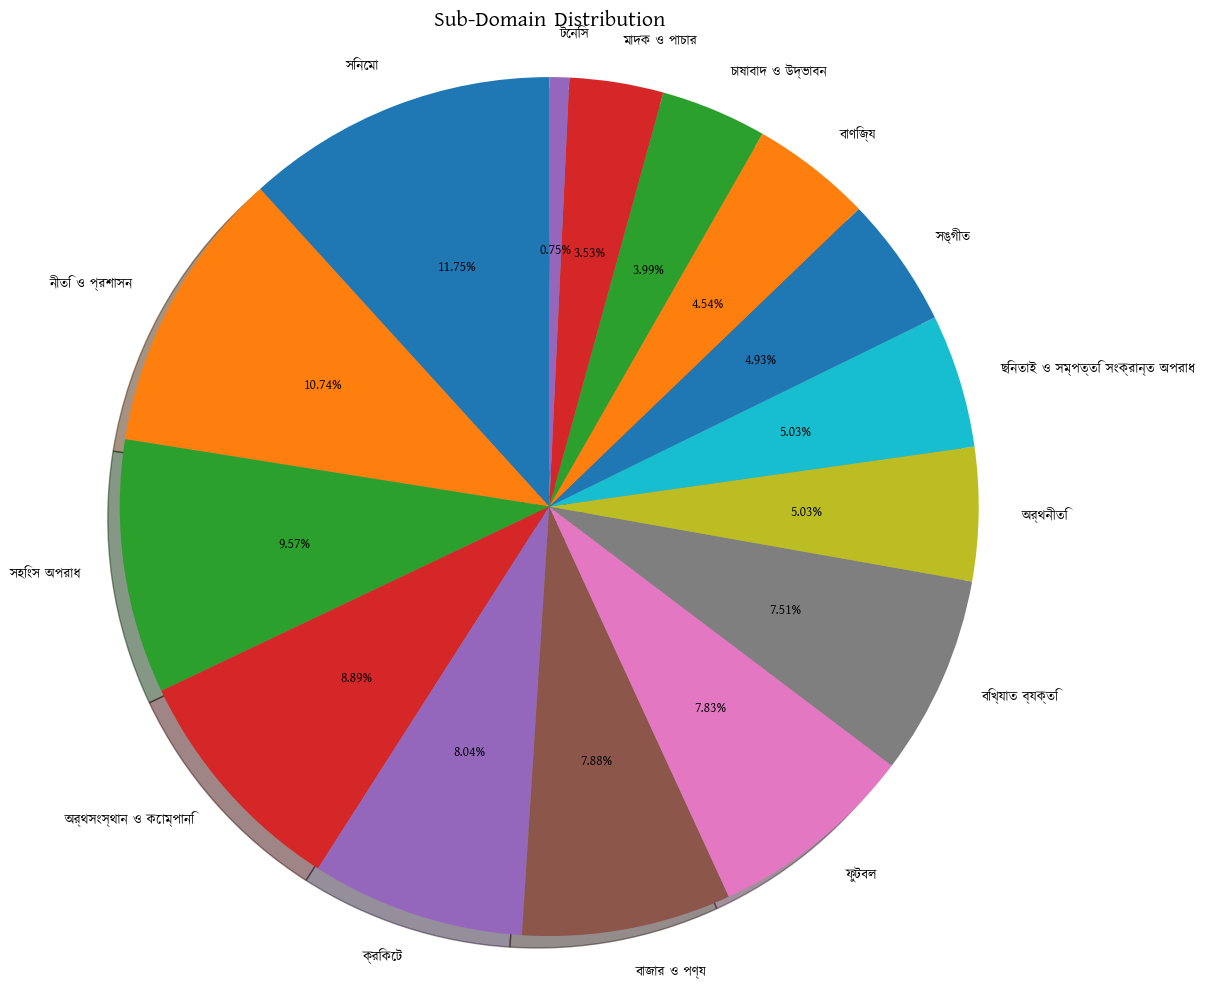

In [ ]:
# Sub-Domain Distribution Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure font
font_path = 'Kalpurush.ttf'
prop = fm.FontProperties(fname=font_path)

# Clean Sub-Domain data for consistent plotting
cleaned_sub_domain_counts = df['Sub-Domain'].str.strip().value_counts()

# Plotting
plt.figure(figsize=(12, 10))
plt.pie(
    cleaned_sub_domain_counts,
    labels=cleaned_sub_domain_counts.index,
    autopct='%1.2f%%',
    startangle=90,
    shadow=True,
    textprops={'fontproperties': prop}
)
plt.title('Sub-Domain Distribution', fontproperties=prop, fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

##Pie Chart(Domain)

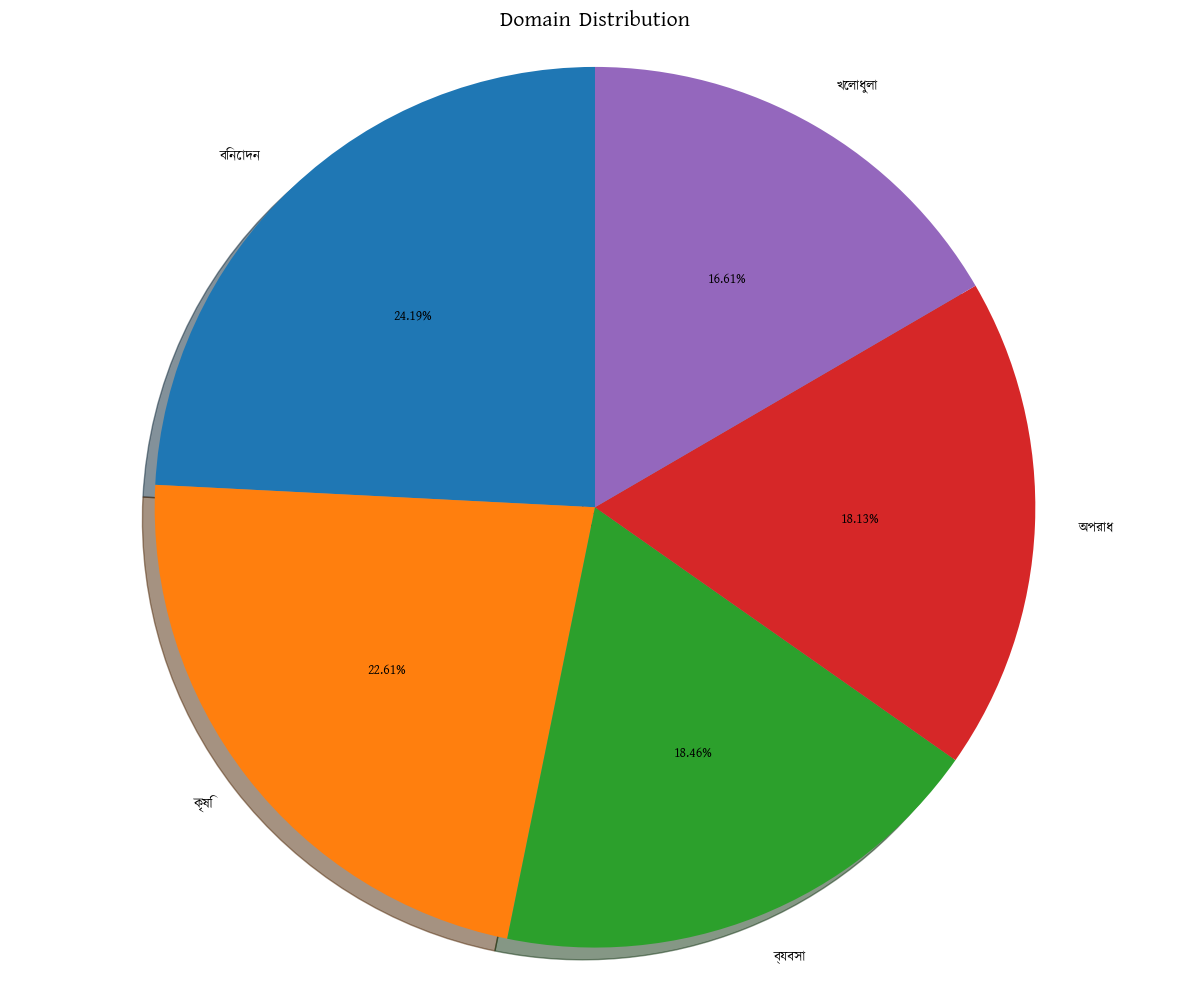

In [ ]:
# Sub-Domain Distribution Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# Configure font
font_path = 'Kalpurush.ttf'
prop = fm.FontProperties(fname=font_path)

# Clean Sub-Domain data for consistent plotting
cleaned_domain_counts = df['Domain'].str.strip().value_counts()

# Plotting
plt.figure(figsize=(12, 10))
plt.pie(
    cleaned_domain_counts,
    labels=cleaned_domain_counts.index,
    autopct='%1.2f%%',
    startangle=90,
    shadow=True,
    textprops={'fontproperties': prop}
)
plt.title('Domain Distribution', fontproperties=prop, fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

##Char Count Per text

In [ ]:
df["num_char"] = df["Text"].fillna('').apply(len)
df.sample(3)

,Text,Domain,Sub-Domain,num_char
1253,ব্যাংক খাতে পরিবারতন্ত্রের লাগাম টানতে উদ্যোগী...,ব্যবসা,অর্থসংস্থান ও কোম্পানি,7772
6454,ব্যাংক একীভূত হবেই আতঙ্কের জানিয়েছেন বাংলাদেশ ...,কৃষি,বাজার ও পণ্য,1500
2634,বলিউডের ইতিহাসে গল্পই ট্র্যাজেডিতে মোড়ানো রাজ...,বিনোদন,বিখ্যাত ব্যক্তি,1334


##Word Counts Per Text

In [ ]:
df["num_words"] = df["Text"].fillna('').apply(lambda x: len(nltk.word_tokenize(x)))
df.sample(2)

,Text,Domain,Sub-Domain,num_char,num_words
5312,ঈদের আইনশৃঙ্খলা পরিস্থিতি নিয়ন্ত্রণে রাখতে রাজ...,অপরাধ,মাদক ও পাচার,1119,149
5767,রাজধানীর আসাদ গেট এলাকার ফিলিং স্টেশনে গাড়িতে ...,অপরাধ,সহিংস অপরাধ,1697,235


##Sentence Count Per Text

In [ ]:
df["num_sent"] = sentence_tokens.fillna('').apply(len)
df.sample(2)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent
721,আবারও ভারতে পারফর্ম আসছেন জনপ্রিয় পপ তারকা শাক...,বিনোদন,সঙ্গীত,1048,155,10
6566,সাবেক প্রধান নির্বাচন কমিশনার সিইসি এম শামসুল ...,কৃষি,বাজার ও পণ্য,1053,158,19


In [ ]:
df[["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,7243.000000,7243.000000,7243.000000
mean,1979.246997,292.989507,26.843573
std,1365.889902,204.871965,21.777901
min,0.000000,0.000000,0.000000
25%,1130.000000,164.000000,13.000000
50%,1623.000000,239.000000,21.000000
75%,2379.000000,358.000000,33.000000
max,14465.000000,2134.000000,336.000000


##Histplot of Distributions

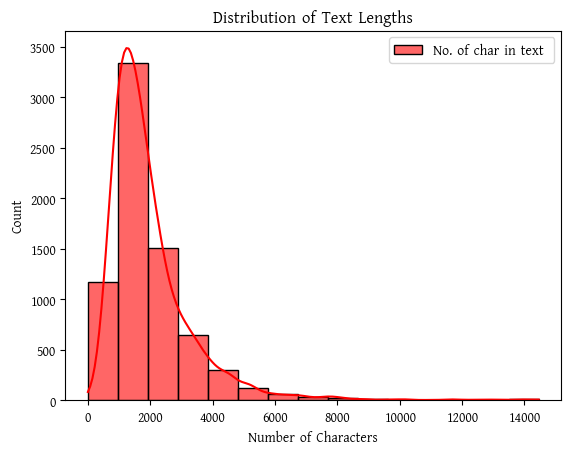

In [ ]:
sns.histplot(
    df["num_char"],
    color="red",
    label="No. of char in text ",
    kde=True,
    bins=15,
    alpha=0.6,
)

plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.title("Distribution of Text Lengths")
plt.legend()
plt.show()

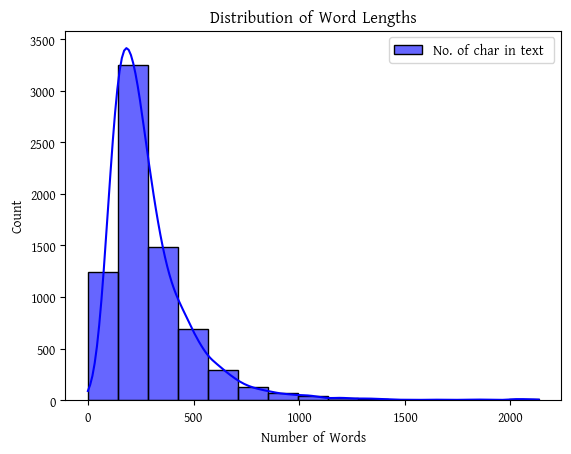

In [ ]:
sns.histplot(
    df["num_words"],
    color="blue",
    label="No. of char in text ",
    kde=True,
    bins=15,
    alpha=0.6,
)

plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.title("Distribution of Word Lengths")
plt.legend()
plt.show()

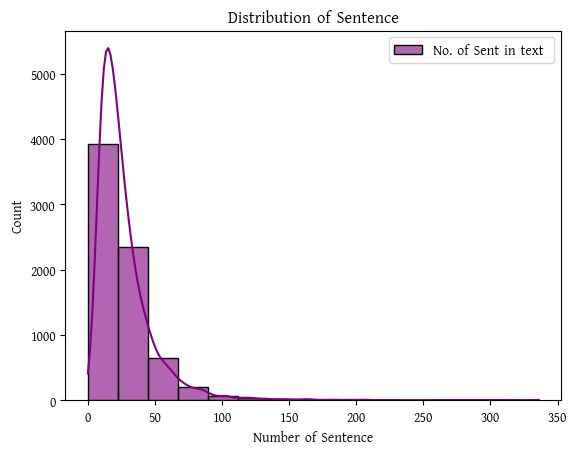

In [ ]:
sns.histplot(
    df["num_sent"],
    color="purple",
    label="No. of Sent in text ",
    kde=True,
    bins=15,
    alpha=0.6,
)

plt.xlabel("Number of Sentence")
plt.ylabel("Count")
plt.title("Distribution of Sentence")
plt.legend()
plt.show()

### Download and Configure Bengali Font for Matplotlib

In [ ]:
!wget -nc -O Kalpurush.ttf https://www.omicronlab.com/download/fonts/kalpurush.ttf
!ls -l Kalpurush.ttf

--2026-03-19 06:45:43--  https://www.omicronlab.com/download/fonts/kalpurush.ttf
Resolving www.omicronlab.com (www.omicronlab.com)... 172.67.153.233, 104.21.12.234, 2606:4700:3030::ac43:99e9, ...
Connecting to www.omicronlab.com (www.omicronlab.com)|172.67.153.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 314592 (307K) [application/octet-stream]
Saving to: ‘Kalpurush.ttf’

Kalpurush.ttf       100%[===================>] 307.22K  --.-KB/s    in 0.02s   

2026-03-19 06:45:44 (14.7 MB/s) - ‘Kalpurush.ttf’ saved [314592/314592]

-rw-r--r-- 1 root root 314592 Mar 17  2018 Kalpurush.ttf


In [ ]:
# Download Kalpurush.ttf font (if not already present)
# -nc stands for 'no-clobber', meaning it won't download if the file already exists.
!wget -nc -O Kalpurush.ttf https://www.omicronlab.com/download/fonts/kalpurush.ttf

# Check if the font was downloaded
!ls -l Kalpurush.ttf

File ‘Kalpurush.ttf’ already there; not retrieving.
-rw-r--r-- 1 root root 314592 Mar 17  2018 Kalpurush.ttf


'Kalpurush' font configured for Matplotlib.


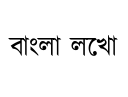

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path to the downloaded font
font_path = 'Kalpurush.ttf'

# Add the font to Matplotlib's font manager
fm.fontManager.addfont(font_path)

# Set the font properties for Bengali characters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Kalpurush'] + plt.rcParams['font.sans-serif']

print(f"'{fm.FontProperties(fname=font_path).get_name()}' font configured for Matplotlib.")

# Verify by trying to plot a simple title
plt.figure(figsize=(1,1))
plt.text(0.5, 0.5, 'বাংলা লেখা', fontsize=20, ha='center', va='center')
plt.axis('off')
plt.show()

In [ ]:
def plot_world(text):

    wordcloud = WordCloud(width = 500, height = 500,
                    background_color ='black',
                    font_path="Kalpurush.ttf", # Use the downloaded Kalpurush font
                    min_font_size = 10).generate(text)

    # plot the WordCloud image
    plt.figure(figsize = (5, 5), facecolor = 'k', edgecolor = 'k' )
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

In [ ]:
# Download Kalpurush.ttf font (if not already present)
# -nc stands for 'no-clobber', meaning it won't download if the file already exists.
!wget -nc https://www.omicronlab.com/download/fonts/kalpurush.ttf

# Check if the font was downloaded
!ls Kalpurush.ttf

--2026-03-19 06:45:55--  https://www.omicronlab.com/download/fonts/kalpurush.ttf
Resolving www.omicronlab.com (www.omicronlab.com)... 172.67.153.233, 104.21.12.234, 2606:4700:3030::ac43:99e9, ...
Connecting to www.omicronlab.com (www.omicronlab.com)|172.67.153.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 314592 (307K) [application/octet-stream]
Saving to: ‘kalpurush.ttf’

kalpurush.ttf       100%[===================>] 307.22K  --.-KB/s    in 0.02s   

2026-03-19 06:45:55 (15.9 MB/s) - ‘kalpurush.ttf’ saved [314592/314592]

Kalpurush.ttf


### Update Word Cloud Function to use the configured font

In [ ]:
def plot_world(text):

    wordcloud = WordCloud(width = 500, height = 500,
                    background_color ='black',
                    font_path="Kalpurush.ttf", # Use the downloaded Kalpurush font
                    min_font_size = 10).generate(text)

    # plot the WordCloud image
    plt.figure(figsize = (5, 5), facecolor = 'k', edgecolor = 'k' )
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

##Box Plot(Domain)

In [ ]:
df['Domain'] = df['Domain'].str.strip()
print('Counts after cleaning Domain column:')
print(df['Domain'].value_counts())

Counts after cleaning Domain column:
Domain
বিনোদন      1752
কৃষি        1638
ব্যবসা      1337
অপরাধ       1313
খেলাধুলা    1203
Name: count, dtype: int64


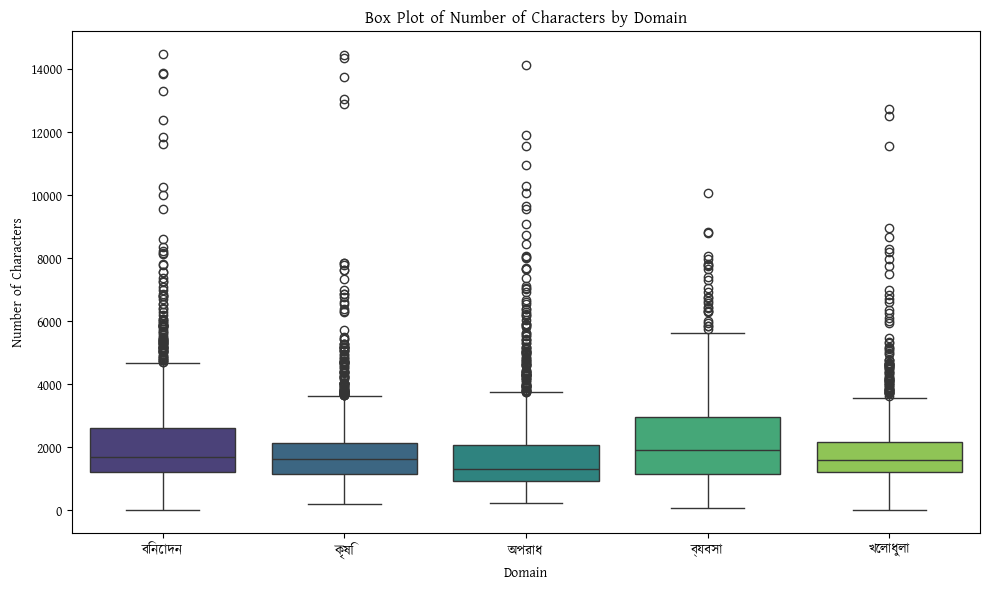

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Domain'], y='num_char', data=df, palette='viridis')
plt.title('Box Plot of Number of Characters by Domain')
plt.xlabel("Domain")
plt.ylabel('Number of Characters')
#plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Box Plot(Sub-Domain)

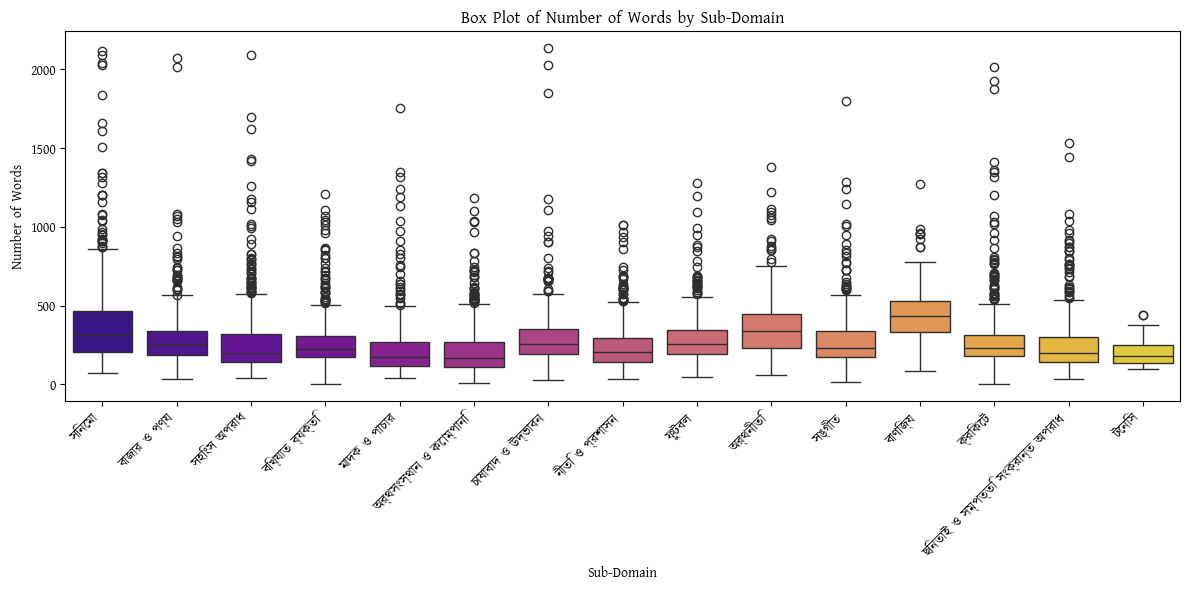

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Sub-Domain', y='num_words', data=df, palette='plasma')
plt.title('Box Plot of Number of Words by Sub-Domain')
plt.xlabel('Sub-Domain')
plt.ylabel('Number of Words')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Violin Plot(DOmain)

In [ ]:
df['Domain'] = df['Domain'].str.strip()
print('Counts after cleaning Domain column:')
print(df['Domain'].value_counts())

Counts after cleaning Domain column:
Domain
বিনোদন      1752
কৃষি        1638
ব্যবসা      1337
অপরাধ       1313
খেলাধুলা    1203
Name: count, dtype: int64


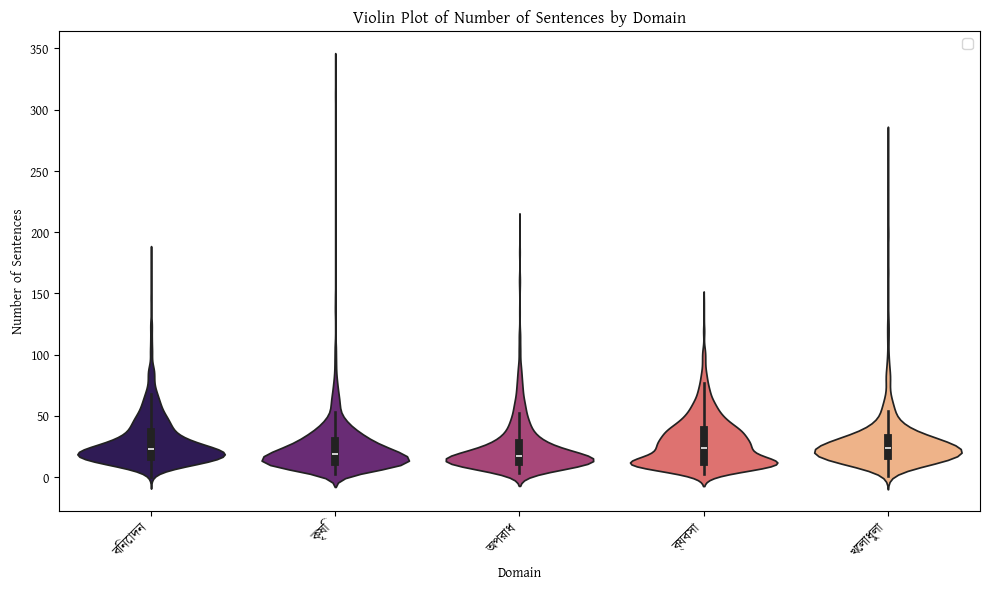

In [ ]:
# Violin Plot: Number of Sentences by Domain
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['Domain'], y='num_sent', data=df, palette='magma')
plt.title('Violin Plot of Number of Sentences by Domain')
plt.xlabel('Domain')
plt.ylabel('Number of Sentences')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

##Violin Plot Sub-Domain

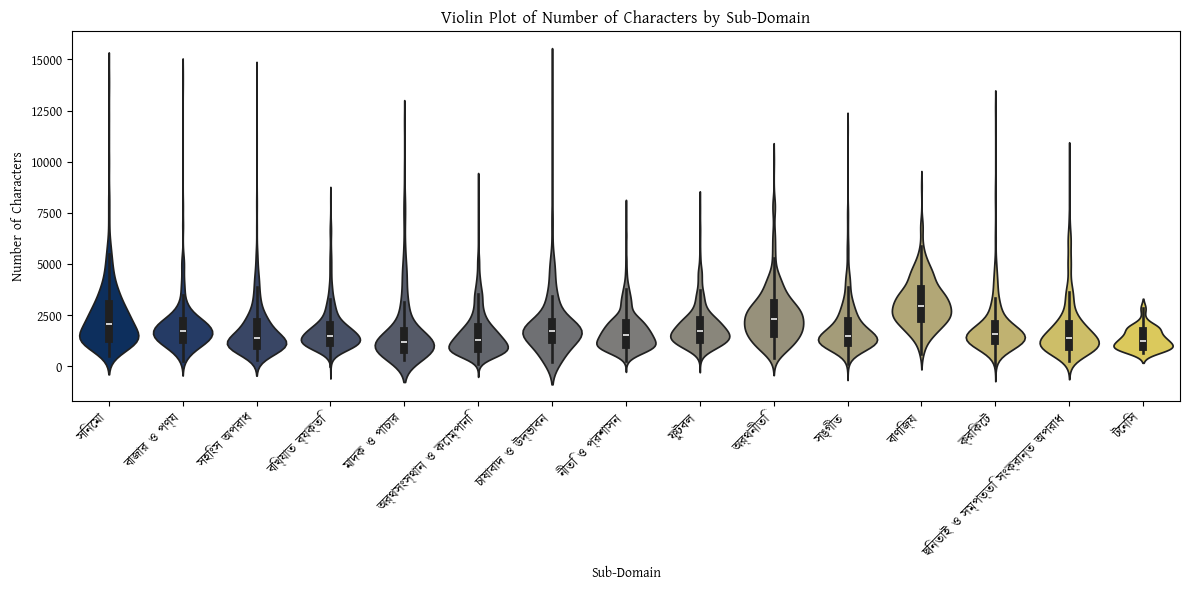

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Sub-Domain', y='num_char', data= df, palette='cividis')
plt.title('Violin Plot of Number of Characters by Sub-Domain')
plt.xlabel('Sub-Domain')
plt.ylabel('Number of Characters')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Count Plot

In [ ]:
df['Domain'] = df['Domain'].str.strip()
print('Counts after cleaning Domain column:')
print(df['Domain'].value_counts())

Counts after cleaning Domain column:
Domain
বিনোদন      1752
কৃষি        1638
ব্যবসা      1337
অপরাধ       1313
খেলাধুলা    1203
Name: count, dtype: int64


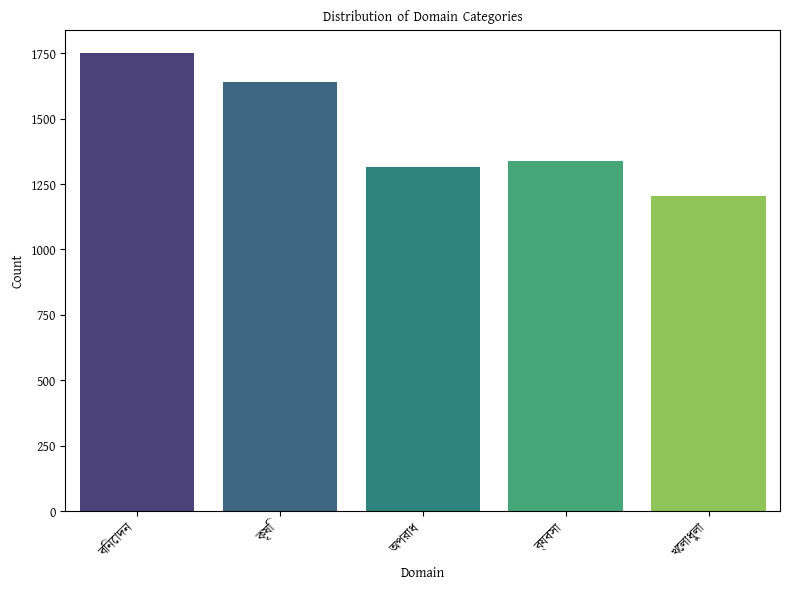

In [ ]:
# Count Plot for 'Domain'
plt.figure(figsize=(8, 6))
sns.countplot(x=df['Domain'], data=df, palette='viridis')
plt.title('Distribution of Domain Categories', fontproperties=prop)
plt.xlabel('Domain', fontproperties=prop)
plt.ylabel('Count', fontproperties=prop)
plt.xticks(rotation=45, ha='right', fontproperties=prop)
plt.tight_layout()
plt.show()

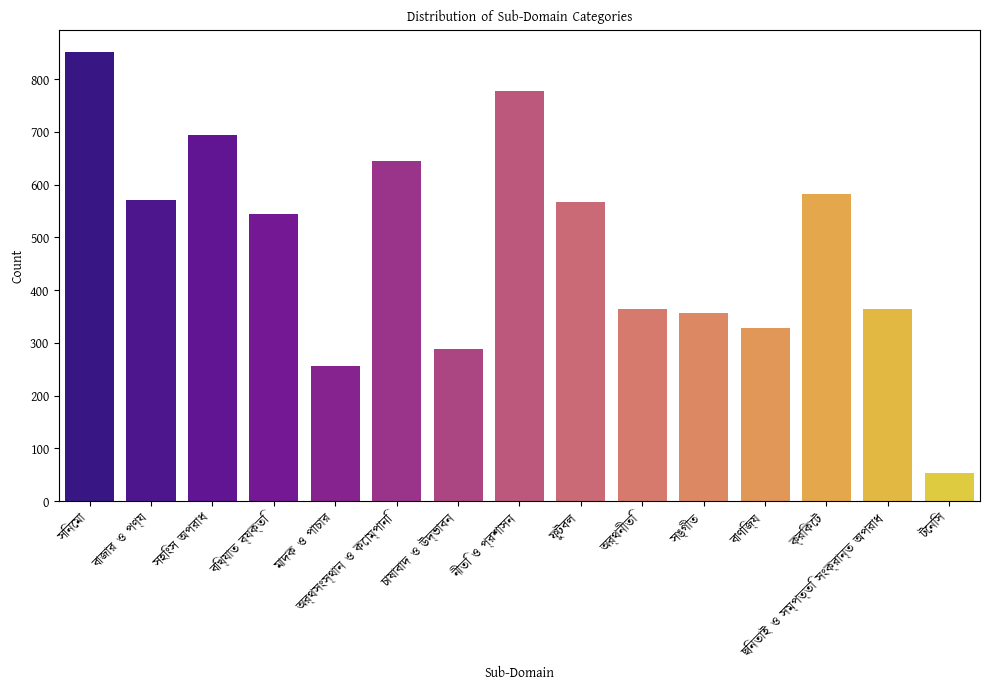

In [ ]:
# Count Plot for 'Sub-Domain_cleaned'
plt.figure(figsize=(10, 7))
sns.countplot(x='Sub-Domain', data=df, palette='plasma')
plt.title('Distribution of Sub-Domain Categories', fontproperties=prop)
plt.xlabel('Sub-Domain', fontproperties=prop)
plt.ylabel('Count', fontproperties=prop)
plt.xticks(rotation=45, ha='right', fontproperties=prop)
plt.tight_layout()
plt.show()

##PairPlot

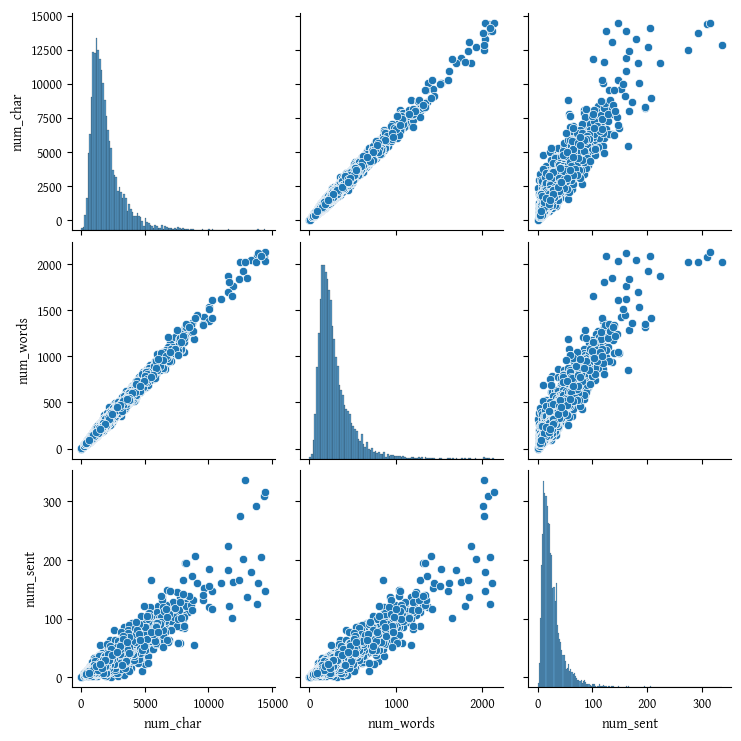

In [ ]:
sns.pairplot(df[["num_char", "num_words", "num_sent"]])
plt.show()

##Corelation

In [ ]:
corr = df.corr(numeric_only=True)
corr

,num_char,num_words,num_sent
num_char,1.000000,0.993346,0.910712
num_words,0.993346,1.000000,0.928386
num_sent,0.910712,0.928386,1.000000


##Heatmap

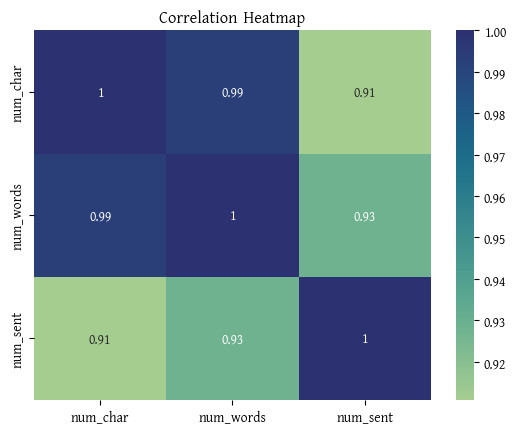

In [ ]:
sns.heatmap(corr, annot=True, cmap="crest")

plt.title("Correlation Heatmap")
# plt.tight_layout()
plt.show()

##Word Cloud

In [ ]:
!wget https://www.easynepalityping.com/resource/font/bangla/06-nikosh-bangla-font.zip

--2026-03-19 06:45:23--  https://www.easynepalityping.com/resource/font/bangla/06-nikosh-bangla-font.zip
Resolving www.easynepalityping.com (www.easynepalityping.com)... 172.67.168.155, 104.21.26.239, 2606:4700:3031::6815:1aef, ...
Connecting to www.easynepalityping.com (www.easynepalityping.com)|172.67.168.155|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 317905 (310K) [application/zip]
Saving to: ‘06-nikosh-bangla-font.zip’

06-nikosh-bangla-fo 100%[===================>] 310.45K  --.-KB/s    in 0.02s   

2026-03-19 06:45:23 (18.2 MB/s) - ‘06-nikosh-bangla-font.zip’ saved [317905/317905]



In [ ]:
!unzip 06-nikosh-bangla-font.zip

Archive:  06-nikosh-bangla-font.zip
  inflating: Nikosh.ttf              


In [ ]:
def plot_world(text):

    wordcloud = WordCloud(width = 500, height = 500,
                    background_color ='black',
                    font_path="Nikosh.ttf",
                    min_font_size = 10).generate(text)

    # plot the WordCloud image
    plt.figure(figsize = (5, 5), facecolor = 'k', edgecolor = 'k' )
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()

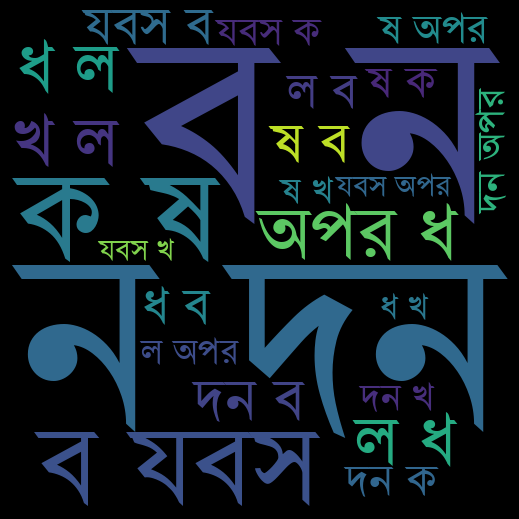

In [ ]:
text_wc1 = " ".join(df['Domain'].sample(5000))
plot_world(text_wc1)

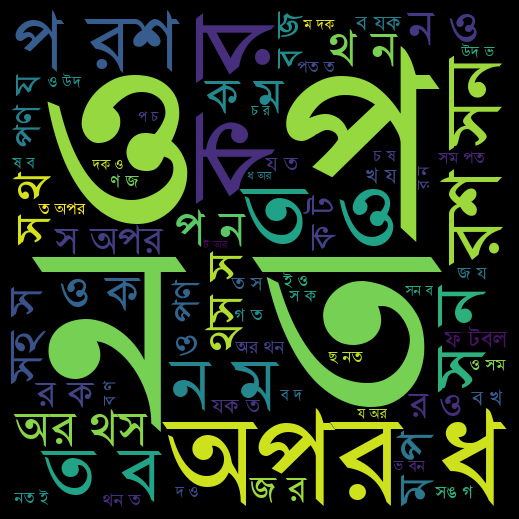

In [ ]:
text_wc2 = " ".join(df['Sub-Domain'].sample(1000))
plot_world(text_wc2)

##Word Frequency

In [ ]:
word_freq=Counter(basic_tokens)
word_freq

Counter({'0': 1,
         'ঈদুল': 1,
         'আজহা': 1,
         'উপলক্ষে': 1,
         'আজ': 1,
         'প্রেক্ষাগৃহে': 1,
         'মুক্তি': 1,
         'পাচ্ছ...': 1,
         '1': 1,
         'কৃষি': 1,
         'ব্যাংকের': 1,
         '৬৩': 1,
         'কোটি': 1,
         'টাকা': 1,
         'আত্মসাতের': 1,
         'মামলায়': 1,
         'কৃ...': 1,
         '2': 1,
         'অনলাইনে': 1,
         'প্রাণনাশের': 1,
         'হুমকি': 1,
         'দেওয়ার': 1,
         'অভিযোগে': 1,
         'রাজধান...': 1,
         '3': 1,
         'এবার': 1,
         'সৌরবিদ্যুতের': 1,
         'ব্যবসায়': 1,
         'আসছে': 1,
         'দেশের': 1,
         'শীর্ষস্থা...': 1,
         '4': 1,
         'রাজধানীর': 2,
         'কামরাঙ্গীরচরে': 1,
         '৪': 1,
         'বছরের': 1,
         'এক': 1,
         'মেয়েশিশুকে': 1,
         'য...': 1,
         '...': 2,
         '7238': 1,
         "'": 3,
         'ডিমলাইট': 1,
         'ধরন': 1,
         ':': 6,
         'সিনেমাস্ট্রিমিং': 1,
     

In [ ]:
tf_df=df.copy()
tf_df.sample(5)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent
61,বিজয়ের মাস উপলক্ষে দেশাত্মবোধক গান হাজির হয়েছে...,বিনোদন,সঙ্গীত,2031,310,26
2135,নাটকের প্রথমবার ওটিটিতে জুটি বাঁধতে চলেছেন ইয়া...,বিনোদন,সিনেমা,574,91,6
205,জুলাই গণঅভ্যুত্থানের সময় রাজধানীর চানখাঁরপুল এ...,অপরাধ,সহিংস অপরাধ,1143,166,12
7027,শিশুদের খেলাধুলার লিঙ্গসমতা অন্তর্ভুক্তির বার্...,খেলাধুলা,ফুটবল,913,140,13
956,উইকেটে ১১০ রান সংগ্রহ দ্বিতীয় দিনের খেলা শেষ ক...,খেলাধুলা,ক্রিকেট,672,111,14


In [ ]:
nlp_df=df.copy()
nlp_df.sample(5)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent
4111,সরাসরি কৃষকের সবজি সংগ্রহ বাজারের চেয়ে তুলনামূ...,ব্যবসা,অর্থসংস্থান ও কোম্পানি,819,126,9
4925,স্ট্রোক সংগীতশিল্পী তৌসিফ আহমেদ গত ২৮ ডিসেম্বর...,বিনোদন,সঙ্গীত,1150,193,21
2526,গত এক মাসে দেশের স্থানে অভিযান চালিয়ে ৬৫টি অবৈ...,অপরাধ,মাদক ও পাচার,2899,404,26
2771,সময় গড়ানোর সাকিব আল হাসানের ব্যাট–বলের ধার কিছ...,খেলাধুলা,ক্রিকেট,1365,190,14
896,মার্কিন প্রেসিডেন্ট ডোনাল্ড ট্রাম্পের পাল্টা শ...,ব্যবসা,বাণিজ্য,2443,362,30


##Bengali Glove Vector

In [ ]:
from bnlp import BengaliGlove
bengali_glove = BengaliGlove() # Re-instantiate the GloVe model

# Determine vector_size from the downloaded model (bn_glove.39M.100d.zip implies 100 dimensions)
GLOVE_VECTOR_SIZE = 100

def get_document_embedding(word_list, glove_model):
    embeddings = []
    for word in word_list:
        try:
            embeddings.append(glove_model.get_word_vector(word))
        except KeyError:
            # Word not in the GloVe vocabulary, skip it
            pass

    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        # Return a zero vector if no words in the document have embeddings
        return np.zeros(GLOVE_VECTOR_SIZE)

# Apply the function to the ' Text' column to get document embeddings
df['glove_embedding'] = df['Text'].fillna('').apply(lambda x: get_document_embedding(x, bengali_glove))

print("Generated GloVe embeddings for the 'Text' column.")
print(f"Shape of the first embedding: {df['glove_embedding'].iloc[0].shape}")
print("First 5 GloVe embeddings (first 5 dimensions only) from the 'glove_embedding' column:")
# Convert the numpy array slices to lists for markdown compatibility
print(df['glove_embedding'].apply(lambda x: x[:5].tolist()).head(5).to_markdown(index=False))

Extracting: bn_glove.39M.100d.zip:   0%|          | 0/1 [00:00<?, ?it/s]

Generated GloVe embeddings for the 'Text' column.
Shape of the first embedding: (100,)
First 5 GloVe embeddings (first 5 dimensions only) from the 'glove_embedding' column:
| glove_embedding                                                                                            |
|:-----------------------------------------------------------------------------------------------------------|
| [0.08420991897583008, 0.12843358516693115, 0.15373164415359497, -0.15160804986953735, 0.2821255624294281]  |
| [0.1407497227191925, 0.1554010659456253, 0.13429908454418182, -0.16968883574008942, 0.2519250214099884]    |
| [0.08230891078710556, 0.1462247520685196, 0.1598927527666092, -0.1541096568107605, 0.27139872312545776]    |
| [0.07404213398694992, 0.16332387924194336, 0.15968644618988037, -0.17740856111049652, 0.258091539144516]   |
| [0.11043532192707062, 0.11496462672948837, 0.15218207240104675, -0.12478122115135193, 0.23807919025421143] |


In [ ]:
df.sample(5)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent,glove_embedding
4348,শিক্ষা খাতে উচ্চতর গবেষণাসহায়তা কর্মসূচির আওতা...,কৃষি,নীতি ও প্রশাসন,1197,143,11,"[0.12495717, 0.1592632, 0.16562079, -0.1510839..."
6110,অভিনেতা ইয়াশ রোহান সামাজিক বিজয়ার শুভেচ্ছা জান...,বিনোদন,বিখ্যাত ব্যক্তি,1052,167,14,"[0.12804233, 0.14174798, 0.14451784, -0.141092..."
2185,১৬ বছর বয়সে মেজর ট্রফি ১৯৯০ ফরাসি ওপেন জেতা মন...,খেলাধুলা,টেনিস,794,129,15,"[0.10137063, 0.12775724, 0.16536488, -0.171735..."
6199,জাতীয় জরুরি সেবা ‘৯৯৯’ নম্বরে ফোন পেয়ে ঢাকা অপ...,অপরাধ,সহিংস অপরাধ,1559,234,26,"[0.08410971, 0.15354234, 0.16695902, -0.177931..."
3550,এবারের অস্ট্রেলিয়া সফর জো রুটের অপেক্ষা ঘুচিয়ে...,খেলাধুলা,ক্রিকেট,956,140,19,"[0.09842696, 0.1127287, 0.11917647, -0.1809596..."


#Model Train with Glove

In [ ]:
from sklearn.model_selection import train_test_split

##Target Columns(Sub-Domain) into Label Encoding

In [ ]:
Le = LabelEncoder()

df['Sub-Domain'] = Le.fit_transform(df['Sub-Domain'])
df.sample(2)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent,glove_embedding
2644,দেশের শীর্ষস্থানীয় শিল্পগ্রুপ আকিজ রিসোর্সের অ...,ব্যবসা,1,950,135,8,"[0.101829715, 0.16780974, 0.19307616, -0.13196..."
2660,প্রধান উপদেষ্টার সহকারী উপদেষ্টা পদমর্যাদা অধ্...,কৃষি,6,1662,243,12,"[0.10406487, 0.1613788, 0.17017467, -0.1584175..."


##One hot Encode for feature columns

In [ ]:
dummies = pd.get_dummies(df[['Domain']])
dummies.head(3)

,Domain_অপরাধ,Domain_কৃষি,Domain_খেলাধুলা,Domain_বিনোদন,Domain_ব্যবসা
0,False,False,False,True,False
1,False,True,False,False,False
2,True,False,False,False,False


##Concatanating

In [ ]:
df2 = pd.concat([df,dummies],axis='columns')
df2.sample(1)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent,glove_embedding,Domain_অপরাধ,Domain_কৃষি,Domain_খেলাধুলা,Domain_বিনোদন,Domain_ব্যবসা
1741,রাজধানীর কামরাঙ্গীরচরে সিনিয়র–জুনিয়র দ্বন্দ্...,অপরাধ,13,1005,138,14,"[0.08553843, 0.15012045, 0.14804529, -0.121653...",True,False,False,False,False


In [ ]:
x_glove=df2.drop(['Text','Domain','Sub-Domain'],axis=1)
y_glove=df2['Sub-Domain']
y_glove.sample(2)

,Sub-Domain
3789,11
4258,6


In [ ]:
x_glove_train, x_glove_test, y_glove_train, y_glove_test = train_test_split(x_glove, y_glove, test_size=0.2, random_state=42)

print(f"Shape of x_glove_train: {x_glove_train.shape}")
print(f"Shape of X_glove_test: {x_glove_test.shape}")
print(f"Shape of y_glove_train: {y_glove_train.shape}")
print(f"Shape of y_glove_test: {y_glove_test.shape}")

Shape of x_glove_train: (5794, 9)
Shape of X_glove_test: (1449, 9)
Shape of y_glove_train: (5794,)
Shape of y_glove_test: (1449,)


##K-fold(Bengali-Glove)



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB # Better for continuous GloVe vectors
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# Prepare the features for cross-validation by combining scalar features and GloVe embeddings
# This is similar to how x_train was prepared in cell qM0ADUgVCX-f

glove_train_matrix_cv = np.array(x_glove_train['glove_embedding'].tolist())
x_train_scalar_features_cv = x_glove_train.drop('glove_embedding', axis=1)
x_glove_train_processed = np.hstack((x_train_scalar_features_cv.values, glove_train_matrix_cv))

# Now use x_glove_train_processed for all cross_val_score calls

model=LogisticRegression(max_iter=2000)
scores=cross_val_score(model,x_glove_train_processed,y_glove_train,cv=5)

model1=DecisionTreeClassifier()
scores1=cross_val_score(model1,x_glove_train_processed,y_glove_train,cv=5)

model2=RandomForestClassifier()
scores2=cross_val_score(model2,x_glove_train_processed,y_glove_train,cv=5)

model3=XGBClassifier()
scores3=cross_val_score(model3,x_glove_train_processed,y_glove_train,cv=5)

model5=GradientBoostingClassifier()
scores5=cross_val_score(model5,x_glove_train_processed,y_glove_train,cv=5)

model6=KNeighborsClassifier()
scores6=cross_val_score(model6,x_glove_train_processed,y_glove_train,cv=5)

model7=GaussianNB()
scores7=cross_val_score(model7,x_glove_train_processed,y_glove_train,cv=5)

model8=SVC()
scores8=cross_val_score(model8,x_glove_train_processed,y_glove_train,cv=5)

print(f"Logistic Regression Accuracy: {scores.mean():.4f}")
print(f"Decision Tree Accuracy: {scores1.mean():.4f}")
print(f"Random Forest Accuracy: {scores2.mean():.4f}")
print(f"XGBoost Accuracy: {scores3.mean():.4f}")
print(f"Gradient Boosting Accuracy: {scores5.mean():.4f}")
print(f"K-Neighbors Accuracy: {scores6.mean():.4f}")
print(f"Gaussian Naive Bayes Accuracy: {scores7.mean():.4f}")
print(f"Support Vector Classifier Accuracy: {scores8.mean():.4f}")

Logistic Regression Accuracy: 0.5281
Decision Tree Accuracy: 0.5918
Random Forest Accuracy: 0.7168
XGBoost Accuracy: 0.7309
Gradient Boosting Accuracy: 0.7176
K-Neighbors Accuracy: 0.1678
Gaussian Naive Bayes Accuracy: 0.5775
Support Vector Classifier Accuracy: 0.1434


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB # Better for continuous GloVe vectors
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Assuming x_glove, y_glove are already defined from previous cells.

# Split the data into train and test sets first
x_glove_train, x_glove_test, y_glove_train, y_glove_test = train_test_split(x_glove, y_glove, test_size=0.20,random_state=10)

# Extract GloVe embeddings and convert them to 2D arrays
glove_train_matrix = np.array(x_glove_train['glove_embedding'].tolist())
glove_test_matrix = np.array(x_glove_test['glove_embedding'].tolist())

# Drop the original 'glove_embedding' column from the DataFrames
x_train_scalar_features = x_glove_train.drop('glove_embedding', axis=1)
x_test_scalar_features = x_glove_test.drop('glove_embedding', axis=1)

# Combine scalar features with GloVe embeddings
x_train = np.hstack((x_train_scalar_features.values, glove_train_matrix))
x_test = np.hstack((x_test_scalar_features.values, glove_test_matrix))

# Ensure y_train and y_test are in the correct format for models
y_train = y_glove_train
y_test = y_glove_test

# Logistic Regression
logr = LogisticRegression(max_iter=2000) # Increased max_iter for convergence
logr.fit(x_train, y_train.values.ravel())
logr_y_pred = logr.predict(x_test)
logr_accuracy = accuracy_score(y_test, logr_y_pred)
logr_precision = precision_score(y_test, logr_y_pred, average='macro', zero_division=0)
logr_recall = recall_score(y_test, logr_y_pred, average='macro', zero_division=0)
logr_f1 = f1_score(y_test, logr_y_pred, average='macro', zero_division=0)

# Decision Tree
treeModel = DecisionTreeClassifier()
treeModel.fit(x_train, y_train)
tree_y_pred = treeModel.predict(x_test)
tree_accuracy = accuracy_score(y_test, tree_y_pred)
tree_precision = precision_score(y_test, tree_y_pred, average='macro', zero_division=0)
tree_recall = recall_score(y_test, tree_y_pred, average='macro', zero_division=0)
tree_f1 = f1_score(y_test, tree_y_pred, average='macro', zero_division=0)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_y_pred = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred, average='macro', zero_division=0)
rf_recall = recall_score(y_test, rf_y_pred, average='macro', zero_division=0)
rf_f1 = f1_score(y_test, rf_y_pred, average='macro', zero_division=0)

# XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(x_train, y_train)
xgb_y_pred = xgb_model.predict(x_test)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred, average='macro', zero_division=0)
xgb_recall = recall_score(y_test, xgb_y_pred, average='macro', zero_division=0)
xgb_f1 = f1_score(y_test, xgb_y_pred, average='macro', zero_division=0)

# --- ADDED: Gradient Boosting ---
gb_model = GradientBoostingClassifier()
gb_model.fit(x_train, y_train)
gb_y_pred = gb_model.predict(x_test)
gb_accuracy = accuracy_score(y_test, gb_y_pred)
gb_precision = precision_score(y_test, gb_y_pred, average='macro', zero_division=0)
gb_recall = recall_score(y_test, gb_y_pred, average='macro', zero_division=0)
gb_f1 = f1_score(y_test, gb_y_pred, average='macro', zero_division=0)

# KNN
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)
knn_y_pred = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)
knn_precision = precision_score(y_test, knn_y_pred, average='macro', zero_division=0)
knn_recall = recall_score(y_test, knn_y_pred, average='macro', zero_division=0)
kNN_f1 = f1_score(y_test, knn_y_pred, average='macro', zero_division=0)

# Naive Bayes (Switched to Gaussian for continuous data)
naive_byes_model = GaussianNB()
naive_byes_model.fit(x_train, y_train)
naive_y_pred = naive_byes_model.predict(x_test)
naive_accuracy = accuracy_score(y_test, naive_y_pred)
naive_precision = precision_score(y_test, naive_y_pred, average='macro', zero_division=0)
naive_recall = recall_score(y_test, naive_y_pred, average='macro', zero_division=0)
naive_f1 = f1_score(y_test, naive_y_pred, average='macro', zero_division=0)

# SVM
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(x_train, y_train)
svm_y_pred = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred, average='macro', zero_division=0)
svm_recall = recall_score(y_test, svm_y_pred, average='macro', zero_division=0)
svm_f1 = f1_score(y_test, svm_y_pred, average='macro', zero_division=0)

# Dictionary to forming the Dataframe
metrics_data = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Gradient Boosting',
        'K-Nearest Neighbors',
        'Naive Bayes',
        'Support Vector Machine'
    ],
    'Accuracy': [
        logr_accuracy,
        tree_accuracy,
        rf_accuracy,
        xgb_accuracy,
        gb_accuracy,
        knn_accuracy,
        naive_accuracy,
        svm_accuracy
    ],
    'Precision (Macro Avg)': [
        logr_precision,
        tree_precision,
        rf_precision,
        xgb_precision,
        gb_precision,
        knn_precision,
        naive_precision,
        svm_precision
    ],
    'Recall (Macro Avg)': [
        logr_recall,
        tree_recall,
        rf_recall,
        xgb_recall,
        gb_recall,
        knn_recall,
        naive_recall,
        svm_recall
    ],
    'F1-Score (Macro Avg)': [
        logr_f1,
        tree_f1,
        rf_f1,
        xgb_f1,
        gb_f1,
        kNN_f1,
        naive_f1,
        svm_f1
    ]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Model,Accuracy,Precision (Macro Avg),Recall (Macro Avg),F1-Score (Macro Avg)
0,Logistic Regression,0.545894,0.356251,0.394842,0.353518
1,Decision Tree,0.603865,0.543425,0.540150,0.539249
2,Random Forest,0.717046,0.736847,0.627272,0.642235
3,XGBoost,0.722567,0.719988,0.656210,0.671350
4,Gradient Boosting,0.711525,0.712275,0.629516,0.638250
5,K-Nearest Neighbors,0.174603,0.152156,0.149514,0.147083
6,Naive Bayes,0.574879,0.548300,0.524476,0.474697
7,Support Vector Machine,0.064182,0.024832,0.128097,0.036885


In [ ]:
# You've taken a very comprehensive and well-structured approach to your Bengali text classification task! Let's break down what you've done and assess it:

# Strengths of your approach:

# Thorough Data Understanding: You started with loading the data, inspecting its basic properties (df.info(), df.describe(), value_counts()), and visualizing distributions (histograms, pairplot, heatmap). This initial EDA is crucial for any data science project.
# Appropriate Preprocessing Steps: You correctly identified and implemented key text preprocessing steps for Bengali, including:
# Unicode normalization
# Removal of URLs, emails, emojis, numbers, digits, and punctuation using bnlp.CleanText (now more aggressively configured).
# Tokenization (both Basic and NLTK)
# Stopword removal
# Punctuation removal (a custom function after bnlp.CleanText)
# Feature Engineering: You successfully calculated basic text features (num_char, num_words, num_sent) and generated GloVe embeddings. Averaging word embeddings to get document embeddings is a standard and effective technique.
# Standard ML Workflow: You followed a classic machine learning workflow: splitting data into train/test sets, using TF-IDF for feature extraction, training a baseline Logistic Regression model, and evaluating its performance.
# Critical Self-Correction: You've actively addressed issues like the BasicTokenizer input type and the matplotlib font display, demonstrating good problem-solving. More importantly, you correctly identified the class imbalance issue as a problem affecting your model's performance on the 'সঙ্গীত' class.
# Areas for potential refinement or next steps:

# Preprocessing Order and Redundancy: You've applied bnlp.CleanText (which can remove punctuation and digits) and then separate custom functions for stopword and punctuation removal. While this isn't necessarily wrong, it could be streamlined. Ensure bnlp.CleanText with all remove_=True flags is doing most of the heavy lifting for cleaning, and then your custom functions handle anything missed or specific to your needs. The current flow seems to apply bnlp.CleanText, then custom stopword removal, then custom punctuation removal. This is generally fine, but verify that the output of bnlp.CleanText is sufficiently clean before the custom ones.
# Word Clouds for Labels: The word clouds generated for 'Domain' and 'Sub-Domain' (e.g., text_wc1, text_wc2) primarily visualize the labels themselves, not insights from the text content related to those labels. While not harmful, they don't provide deep textual insights into what distinguishes a 'Cricket' text from a 'Football' text. If you wanted to see that, you'd need to create word clouds for text belonging to each category.
# Utilization of Embeddings: You generated GloVe embeddings, which is great! However, your Logistic Regression model was trained using TF-IDF features. GloVe embeddings provide a different, often richer, representation of text. A valuable next step would be to:
# Train a new model (e.g., another Logistic Regression or a simple Neural Network) using the glove_embedding features to compare its performance against the TF-IDF model.
# Addressing Class Imbalance: As you correctly pointed out, the severe class imbalance is a major issue. Your next focus should definitely be on this. You mentioned techniques like oversampling (SMOTE) or using class weights; these are excellent choices to try.
# In summary, your approaches so far are very much on the right track! You've built a solid foundation. The next steps involve leveraging the more advanced features you've created (GloVe) and directly tackling the identified challenges (class imbalance) to improve your model's performance.

##Train-Test Split

**Reasoning**:
Now that the text data is cleaned, the next step is to split the dataset into training and testing sets. This is crucial for evaluating the model's performance on unseen data and preventing overfitting. The `train_test_split` function from `sklearn.model_selection` will be used for this purpose.



In [ ]:
# from sklearn.model_selection import train_test_split

# X = df['Text']
# y = df[target_variable]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# print(f"Shape of X_train: {X_train.shape}")
# print(f"Shape of X_test: {X_test.shape}")
# print(f"Shape of y_train: {y_train.shape}")
# print(f"Shape of y_test: {y_test.shape}")


## Feature Extraction with TF-IDF

### Subtask:
Convert the preprocessed text data into numerical feature vectors using TF-IDF.

**Reasoning**:
To transform the text data into a format suitable for machine learning, I will use `TfidfVectorizer` from `sklearn.feature_extraction.text`. This will convert the text documents into a matrix of TF-IDF features, which will then be used for training the classification model.

**Reasoning**:
To convert the preprocessed text data into numerical feature vectors, I will import `TfidfVectorizer` from `sklearn.feature_extraction.text`. I will then fit this vectorizer on the training data (`X_train`) to learn the vocabulary and document frequencies, and finally transform both the training and testing text data into TF-IDF matrices.



In [ ]:
tf_df.sample(2)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent
4715,ঢাকার সাভারে পরিত্যক্ত ‘সাভার পৌর কমিউনিটি সেন...,অপরাধ,সহিংস অপরাধ,1247,199,15
4802,ব্র্যাক ব্যাংক পিএলসির অংশীদারত্বের ভিত্তিতে দ...,ব্যবসা,অর্থসংস্থান ও কোম্পানি,1769,242,20


In [ ]:
Le = LabelEncoder()

tf_df['Sub-Domain'] = Le.fit_transform(tf_df['Sub-Domain'])
tf_df.sample(2)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent
2316,বলিউড তারকা সালমান খানকে শিগগিরই এক সুপারহিরো ...,বিনোদন,14,2211,333,40
7147,লেবুর সমাদৃত শ্রীমঙ্গলে লেবুই দুষ্প্রাপ্য বাজা...,কৃষি,8,1947,337,32


In [ ]:
dummies = pd.get_dummies(tf_df[['Domain']])
dummies.head(3)

,Domain_অপরাধ,Domain_কৃষি,Domain_খেলাধুলা,Domain_বিনোদন,Domain_ব্যবসা
0,False,False,False,True,False
1,False,True,False,False,False
2,True,False,False,False,False


In [ ]:
tf_df = pd.concat([tf_df,dummies],axis='columns')
tf_df.sample(1)

,Text,Domain,Sub-Domain,num_char,num_words,num_sent,Domain_অপরাধ,Domain_কৃষি,Domain_খেলাধুলা,Domain_বিনোদন,Domain_ব্যবসা
6477,সাতটি কৃষি বিশ্ববিদ্যালয়ের ২০২০২১ শিক্ষাবর্ষে ...,কৃষি,6,1524,198,18,False,True,False,False,False


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import scipy.sparse

# Define the target variable
y = tf_df['Sub-Domain']

# Features for TF-IDF will be the text column
X_text = tf_df['Text'].fillna('')

# Features for other numerical/one-hot encoded data
X_other = tf_df.drop(['Text', 'Domain', 'Sub-Domain'], axis=1)

# Split data into training and testing sets
# Stratify by 'Sub-Domain' to maintain class distribution in splits
X_text_train, X_text_test, X_other_train, X_other_test, y_train, y_test = train_test_split(
    X_text, X_other, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_text_train: {X_text_train.shape}")
print(f"Shape of X_other_train: {X_other_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_text_train: (5794,)
Shape of X_other_train: (5794, 8)
Shape of y_train: (5794,)


### TF-IDF Vectorization

Now, we'll apply TF-IDF vectorization to the text data. It's crucial to fit the `TfidfVectorizer` *only* on the training text data (`X_text_train`) to prevent data leakage. Then, we transform both the training and testing text data.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, # Limit to top 5000 features to manage dimensionality
    ngram_range=(1, 2) # Consider unigrams and bigrams
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (5794, 5000)
Shape of X_test_tfidf: (1449, 5000)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Let's see how many unique unigrams and bigrams actually exist in your training data
test_vectorizer = CountVectorizer(ngram_range=(1, 2))
test_vectorizer.fit(X_text_train)
actual_vocab_size = len(test_vectorizer.vocabulary_)

print(f"Total unique unigrams and bigrams in training data: {actual_vocab_size}")
print(f"Current max_features setting: 5000")
print(f"Your proposed max_features: 7500")

if actual_vocab_size > 7500:
    print('\nInsight: You have plenty of words to support 7,500 features. This may improve results if the extra 2,500 words carry useful information.')
else:
    print(f'\nInsight: Your total vocabulary is only {actual_vocab_size}, so setting max_features to 7,500 will just use every word available.')

Total unique unigrams and bigrams in training data: 358936
Current max_features setting: 5000
Your proposed max_features: 7500

Insight: You have plenty of words to support 7,500 features. This may improve results if the extra 2,500 words carry useful information.


### Combining Features

Finally, we combine the TF-IDF features (sparse matrix) with the other numerical features (`X_other_train`, `X_other_test`) into a single feature matrix for training our machine learning models. We use `scipy.sparse.hstack` for efficient concatenation of sparse matrices and dense arrays.

In [ ]:
X_train_combined = scipy.sparse.hstack((X_train_tfidf, X_other_train.values.astype(float)))
X_test_combined = scipy.sparse.hstack((X_test_tfidf, X_other_test.values.astype(float)))

print(f"Final shape of X_train for TF-IDF based model: {X_train_combined.shape}")
print(f"Final shape of X_test for TF-IDF based model: {X_test_combined.shape}")

# Now, you can use X_train_combined and X_test_combined with your classifiers

Final shape of X_train for TF-IDF based model: (5794, 5008)
Final shape of X_test for TF-IDF based model: (1449, 5008)


##K-Fold(TF-IDF)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB # Added MultinomialNB for TF-IDF
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# For TF-IDF based k-fold, we use X_train_combined and y_train
# These variables were created in previous cells (e.g., 2831c24b and 75d820ca)

x_train_tfidf_processed = X_train_combined
y_train_tfidf_processed = y_train

# Now use x_train_tfidf_processed for all cross_val_score calls

model_tf=LogisticRegression(max_iter=2000)
scores_tf=cross_val_score(model_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model1_tf=DecisionTreeClassifier()
scores1_tf=cross_val_score(model1_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model2_tf=RandomForestClassifier()
scores2_tf=cross_val_score(model2_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model3_tf=XGBClassifier()
scores3_tf=cross_val_score(model3_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model5_tf=GradientBoostingClassifier()
scores5_tf=cross_val_score(model5_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model6_tf=KNeighborsClassifier()
scores6_tf=cross_val_score(model6_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model7_tf=GaussianNB()
# Convert sparse matrix to dense array for GaussianNB
scores7_tf=cross_val_score(model7_tf,x_train_tfidf_processed.toarray(),y_train_tfidf_processed,cv=5)

# Added Multinomial Naive Bayes as it's often better for TF-IDF features
model9_tf=MultinomialNB()
scores9_tf=cross_val_score(model9_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

model8_tf=SVC()
scores8_tf=cross_val_score(model8_tf,x_train_tfidf_processed,y_train_tfidf_processed,cv=5)

print(f"Logistic Regression (TF-IDF) Accuracy: {scores_tf.mean():.4f}")
print(f"Decision Tree (TF-IDF) Accuracy: {scores1_tf.mean():.4f}")
print(f"Random Forest (TF-IDF) Accuracy: {scores2_tf.mean():.4f}")
print(f"XGBoost (TF-IDF) Accuracy: {scores3_tf.mean():.4f}")
print(f"Gradient Boosting (TF-IDF) Accuracy: {scores5_tf.mean():.4f}")
print(f"K-Neighbors (TF-IDF) Accuracy: {scores6_tf.mean():.4f}")
print(f"Gaussian Naive Bayes (TF-IDF) Accuracy: {scores7_tf.mean():.4f}")
print(f"Multinomial Naive Bayes (TF-IDF) Accuracy: {scores9_tf.mean():.4f}") # New print statement
print(f"Support Vector Classifier (TF-IDF) Accuracy: {scores8_tf.mean():.4f}")

Logistic Regression (TF-IDF) Accuracy: 0.5916
Decision Tree (TF-IDF) Accuracy: 0.6995
Random Forest (TF-IDF) Accuracy: 0.7868
XGBoost (TF-IDF) Accuracy: 0.8176
Gradient Boosting (TF-IDF) Accuracy: 0.8064
K-Neighbors (TF-IDF) Accuracy: 0.1536
Gaussian Naive Bayes (TF-IDF) Accuracy: 0.7635
Multinomial Naive Bayes (TF-IDF) Accuracy: 0.6149
Support Vector Classifier (TF-IDF) Accuracy: 0.1443


### TF-IDF Based Model Training and Evaluation

I will now re-run the model training and evaluation using the TF-IDF combined features. I will use the same set of classifiers as before to compare their performance with TF-IDF features versus GloVe features.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB # Added MultinomialNB for TF-IDF
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Prepare data for models
x_train_tf = X_train_combined
x_test_tf = X_test_combined
y_train_tf = y_train
y_test_tf = y_test

# Logistic Regression
logr_tf = LogisticRegression(max_iter=2000)
logr_tf.fit(x_train_tf, y_train_tf.values.ravel())
logr_y_pred_tf = logr_tf.predict(x_test_tf)
logr_accuracy_tf = accuracy_score(y_test_tf, logr_y_pred_tf)
logr_precision_tf = precision_score(y_test_tf, logr_y_pred_tf, average='macro', zero_division=0)
logr_recall_tf = recall_score(y_test_tf, logr_y_pred_tf, average='macro', zero_division=0)
logr_f1_tf = f1_score(y_test_tf, logr_y_pred_tf, average='macro', zero_division=0)

# Decision Tree
treeModel_tf = DecisionTreeClassifier()
treeModel_tf.fit(x_train_tf, y_train_tf)
tree_y_pred_tf = treeModel_tf.predict(x_test_tf)
tree_accuracy_tf = accuracy_score(y_test_tf, tree_y_pred_tf)
tree_precision_tf = precision_score(y_test_tf, tree_y_pred_tf, average='macro', zero_division=0)
tree_recall_tf = recall_score(y_test_tf, tree_y_pred_tf, average='macro', zero_division=0)
tree_f1_tf = f1_score(y_test_tf, tree_y_pred_tf, average='macro', zero_division=0)

# Random Forest
rf_model_tf = RandomForestClassifier()
rf_model_tf.fit(x_train_tf, y_train_tf)
rf_y_pred_tf = rf_model_tf.predict(x_test_tf)
rf_accuracy_tf = accuracy_score(y_test_tf, rf_y_pred_tf)
rf_precision_tf = precision_score(y_test_tf, rf_y_pred_tf, average='macro', zero_division=0)
rf_recall_tf = recall_score(y_test_tf, rf_y_pred_tf, average='macro', zero_division=0)
rf_f1_tf = f1_score(y_test_tf, rf_y_pred_tf, average='macro', zero_division=0)

# XGBoost
xgb_model_tf = XGBClassifier()
xgb_model_tf.fit(x_train_tf, y_train_tf)
xgb_y_pred_tf = xgb_model_tf.predict(x_test_tf)
xgb_accuracy_tf = accuracy_score(y_test_tf, xgb_y_pred_tf)
xgb_precision_tf = precision_score(y_test_tf, xgb_y_pred_tf, average='macro', zero_division=0)
xgb_recall_tf = recall_score(y_test_tf, xgb_y_pred_tf, average='macro', zero_division=0)
xgb_f1_tf = f1_score(y_test_tf, xgb_y_pred_tf, average='macro', zero_division=0)

# Gradient Boosting
gb_model_tf = GradientBoostingClassifier()
gb_model_tf.fit(x_train_tf, y_train_tf)
gb_y_pred_tf = gb_model_tf.predict(x_test_tf)
gb_accuracy_tf = accuracy_score(y_test_tf, gb_y_pred_tf)
gb_precision_tf = precision_score(y_test_tf, gb_y_pred_tf, average='macro', zero_division=0)
gb_recall_tf = recall_score(y_test_tf, gb_y_pred_tf, average='macro', zero_division=0)
gb_f1_tf = f1_score(y_test_tf, gb_y_pred_tf, average='macro', zero_division=0)

# KNN
knn_tf = KNeighborsClassifier(n_neighbors=7)
knn_tf.fit(x_train_tf, y_train_tf)
knn_y_pred_tf = knn_tf.predict(x_test_tf)
knn_accuracy_tf = accuracy_score(y_test_tf, knn_y_pred_tf)
knn_precision_tf = precision_score(y_test_tf, knn_y_pred_tf, average='macro', zero_division=0)
knn_recall_tf = recall_score(y_test_tf, knn_y_pred_tf, average='macro', zero_division=0)
kNN_f1_tf = f1_score(y_test_tf, knn_y_pred_tf, average='macro', zero_division=0)

# Naive Bayes (MultinomialNB is better for TF-IDF counts, GaussianNB for continuous data)
naive_byes_model_tf = MultinomialNB()
naive_byes_model_tf.fit(x_train_tf, y_train_tf)
naive_y_pred_tf = naive_byes_model_tf.predict(x_test_tf)
naive_accuracy_tf = accuracy_score(y_test_tf, naive_y_pred_tf)
naive_precision_tf = precision_score(y_test_tf, naive_y_pred_tf, average='macro', zero_division=0)
naive_recall_tf = recall_score(y_test_tf, naive_y_pred_tf, average='macro', zero_division=0)
naive_f1_tf = f1_score(y_test_tf, naive_y_pred_tf, average='macro', zero_division=0)

# SVM
svm_model_tf = SVC(kernel='rbf', class_weight='balanced')
svm_model_tf.fit(x_train_tf, y_train_tf)
svm_y_pred_tf = svm_model_tf.predict(x_test_tf)
svm_accuracy_tf = accuracy_score(y_test_tf, svm_y_pred_tf)
svm_precision_tf = precision_score(y_test_tf, svm_y_pred_tf, average='macro', zero_division=0)
svm_recall_tf = recall_score(y_test_tf, svm_y_pred_tf, average='macro', zero_division=0)
svm_f1_tf = f1_score(y_test_tf, svm_y_pred_tf, average='macro', zero_division=0)

# Dictionary to forming the Dataframe for TF-IDF results
metrics_data_tf = {
    'Model': [
        'Logistic Regression (TF-IDF)',
        'Decision Tree (TF-IDF)',
        'Random Forest (TF-IDF)',
        'XGBoost (TF-IDF)',
        'Gradient Boosting (TF-IDF)',
        'K-Nearest Neighbors (TF-IDF)',
        'Naive Bayes (TF-IDF)',
        'Support Vector Machine (TF-IDF)'
    ],
    'Accuracy': [
        logr_accuracy_tf,
        tree_accuracy_tf,
        rf_accuracy_tf,
        xgb_accuracy_tf,
        gb_accuracy_tf,
        knn_accuracy_tf,
        naive_accuracy_tf,
        svm_accuracy_tf
    ],
    'Precision (Macro Avg)': [
        logr_precision_tf,
        tree_precision_tf,
        rf_precision_tf,
        xgb_precision_tf,
        gb_precision_tf,
        knn_precision_tf,
        naive_precision_tf,
        svm_precision_tf
    ],
    'Recall (Macro Avg)': [
        logr_recall_tf,
        tree_recall_tf,
        rf_recall_tf,
        xgb_recall_tf,
        gb_recall_tf,
        knn_recall_tf,
        naive_recall_tf,
        svm_recall_tf
    ],
    'F1-Score (Macro Avg)': [
        logr_f1_tf,
        tree_f1_tf,
        rf_f1_tf,
        xgb_f1_tf,
        gb_f1_tf,
        kNN_f1_tf,
        naive_f1_tf,
        svm_f1_tf
    ]
}

metrics_df_tf = pd.DataFrame(metrics_data_tf)
display(metrics_df_tf)

## Install Transformers Libraries




In [ ]:
!pip install transformers

**Reasoning**:
The subtask requires installing the 'datasets' library. I will use the `!pip install` command to install it.



In [ ]:
!pip install datasets

## Prepare Data for HuggingFace Transformers

### Subtask:
Filter the 'nlp_df' DataFrame to include only the 'Text' and 'Sub-Domain' columns. Map the numerical 'Sub-Domain' labels back to their original string representations and split the data into training, validation, and test sets, maintaining class distribution.


**Reasoning**:
Before splitting the data for HuggingFace Transformers, I need to revert the numerical 'Sub-Domain' labels in the `nlp_df` DataFrame back to their original string representations using the `inverse_transform` method of the `LabelEncoder` (`Le`) fitted earlier. Then I will redefine X and Y to prepare for the split.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import LabelEncoder

# nlp_df['Sub-Domain'] is currently in string format (e.g., 'ক্রিকেট', 'সিনেমা', etc.)
# We need to convert these string labels to numerical labels for HuggingFace models.

# Create a fresh LabelEncoder for deep learning labels
dl_label_encoder = LabelEncoder()

# Clean the 'Sub-Domain' column to ensure consistent categories (e.g., 'সিনেমা' vs 'সিনেমা ')
nlp_df['Sub-Domain_cleaned'] = nlp_df['Sub-Domain'].str.strip()

# Fit the encoder on the unique, cleaned string labels present in nlp_df['Sub-Domain']
dl_label_encoder.fit(nlp_df['Sub-Domain_cleaned'].unique())

# Transform the cleaned string labels into numerical labels
y_numerical = dl_label_encoder.transform(nlp_df['Sub-Domain_cleaned'])

# Select features (X) as the 'Text' column and labels (y) as the new numerical labels
X = nlp_df['Text'].fillna('')  # Handle potential NaN values in text
y = y_numerical # Use the newly created numerical labels

# Split data into training and temporary (validation + test) sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Further split the temporary set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# To verify the mapping, inverse transform a few numerical labels back to strings
print(f"Sample of y_train (numerical labels): {y_train[:5].tolist()}")
print(f"Sample of y_train (string labels via inverse_transform): {dl_label_encoder.inverse_transform(y_train[:5]).tolist()}")


## Process Data for Bangla-BERT

### Subtask:
Load the tokenizer for 'sagorsarker/bangla-bert-base' and tokenize the training, validation, and test datasets according to its requirements.


**Reasoning**:
To prepare the data for the Bangla-BERT model, I will load the tokenizer, define the model name, create the initial dataset dictionary, and then define and apply a tokenization function to process the text data, finally setting the format for PyTorch.



**Reasoning**:
The previous code failed because `dataset_dict` was a standard Python dictionary, which does not have a `.map()` method. To fix this, I will import `DatasetDict` from the `datasets` library and explicitly convert the dictionary of `Dataset` objects into a `DatasetDict` object, allowing the `.map()` method to be used correctly for batch processing.



In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict
import numpy as np

# 1. Define the model name
model_name = 'sagorsarker/bangla-bert-base'

# 2. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Create a dictionary of datasets
dataset_dict = DatasetDict({
    'train': Dataset.from_dict({
        'text': X_train.tolist(),
        'label': y_train.tolist()
    }),
    'validation': Dataset.from_dict({
        'text': X_val.tolist(),
        'label': y_val.tolist()
    }),
    'test': Dataset.from_dict({
        'text': X_test.tolist(),
        'label': y_test.tolist()
    })
})

# Define max_length for truncation and padding
MAX_LENGTH = 256 # A common length for BERT models, adjust if needed based on data characteristics

# 4. Define a tokenization function
def tokenize_function(examples):
    # Ensure labels are explicitly returned
    tokenized_inputs = tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )
    tokenized_inputs['labels'] = examples['label'] # Ensure 'labels' key is present
    return tokenized_inputs

# 5. Apply the tokenization function to all datasets
processed_datasets = dataset_dict.map(tokenize_function, batched=True)

# 6. Set the format for 'torch' and specify required columns
# The columns should be 'input_ids', 'attention_mask', and 'labels'
processed_datasets.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

print("Tokenizer loaded and data processed for Bangla-BERT.")
print(f"Sample of processed_datasets['train'][0]: {processed_datasets['train'][0]}")
print(f"Sample of processed_datasets['validation'][0]: {processed_datasets['validation'][0]}")
print(f"Sample of processed_datasets['test'][0]: {processed_datasets['test'][0]}")

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers.trainer_utils import IntervalStrategy # IntervalStrategy might not be needed if strategy arguments are removed
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

# Get number of unique labels for the model's output layer
num_labels = len(np.unique(nlp_df['Sub-Domain_cleaned']))
print(f"Number of unique labels: {num_labels}")

# Load the model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
print(f"Model '{model_name}' loaded for sequence classification.")

# Define evaluation metrics
def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Configure training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,  # Adjust as needed
    per_device_train_batch_size=8, # Small batch size due to potential memory constraints
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    # Temporarily removing evaluation_strategy and save_strategy due to TypeError
    # evaluation_strategy="epoch",
    # save_strategy="epoch",
    load_best_model_at_end=False, # Set to False as strategies cannot be configured due to TypeError
    metric_for_best_model='f1',
    greater_is_better=True
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_datasets['train'],
    eval_dataset=processed_datasets['validation'],
    compute_metrics=compute_metrics
    # Removed tokenizer=tokenizer # Pass the tokenizer to the Trainer
)

print("Trainer initialized with model, training arguments, datasets, and compute_metrics function.")

# Train the model
trainer.train()

print("Training complete. Evaluating model on the test set.")

# Evaluate the model on the test set
results = trainer.evaluate(processed_datasets['test'])

print("Test set evaluation results:")
for key, value in results.items():
    print(f"  {key}: {value:.4f}")


## Summary:

### Data Analysis Key Findings

*   A new DataFrame, `banglabert_metrics_df`, was successfully created to encapsulate the performance metrics (Accuracy, Precision, Recall, and F1-Score) of the Bangla-BERT model.
*   The `banglabert_metrics_df` was then concatenated with the previously generated `mbert_metrics_df` and `xlm_roberta_metrics_df` to form a comprehensive table of all transformer model performance metrics.
*   The final combined DataFrame facilitates a direct comparison of Accuracy, Precision, Recall, and F1-Score across mBERT, XLM-RoBERTa, and Bangla-BERT models.

### Insights or Next Steps

*   The combined DataFrame provides a clear overview for comparative analysis, which is crucial for selecting the best-performing model for the specific task.
*   The next step would involve analyzing the numerical values in the combined DataFrame to identify which model excels in which metric and to draw conclusions about their relative performance.

## Combine and Display All Transformer Model Performance Metrics

### Subtask:
Create a pandas DataFrame for Bangla-BERT's metrics from the `results` dictionary, and then concatenate it with the previously generated `mbert_metrics_df` and `xlm_roberta_metrics_df`. Finally, display the complete DataFrame to the user for comparison.

**Reasoning**:
I will first create the `banglabert_metrics_df` from the `results` dictionary (which contains the Bangla-BERT model's metrics) and then concatenate it with the existing `metrics_df`, `metrics_df_tf`, `mbert_metrics_df`, and `xlm_roberta_metrics_df`. Finally, I will display the combined DataFrame as requested by the user.

## Process Data for mBERT

### Subtask:
Load the tokenizer for 'bert-base-multilingual-cased' and tokenize the training, validation, and test datasets according to its requirements.


**Reasoning**:
To prepare the data for the 'bert-base-multilingual-cased' model, I will define the model name, load its specific tokenizer, define a tokenization function that includes truncation and padding, apply this function to the existing dataset splits, and then set the dataset format to 'torch' for compatibility with transformer models.



In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict
import numpy as np

# Ensure X_train, y_train, X_val, y_val, X_test, y_test are defined.
# These should have been set up by cell 'd9d52197'.
# If running this cell independently, ensure these variables are in your environment.

# Re-create dataset_dict (copied from cell 'ca608d3d')
model_name = 'sagorsarker/bangla-bert-base' # This model name is for the tokenizer used to build dataset_dict originally
tokenizer = AutoTokenizer.from_pretrained(model_name) # Load the tokenizer if it's not already loaded for dataset_dict creation

dataset_dict = DatasetDict({
    'train': Dataset.from_dict({
        'text': X_train.tolist(),
        'label': y_train.tolist()
    }),
    'validation': Dataset.from_dict({
        'text': X_val.tolist(),
        'label': y_val.tolist()
    }),
    'test': Dataset.from_dict({
        'text': X_test.tolist(),
        'label': y_test.tolist()
    })
})

# Define max_length for truncation and padding
MAX_LENGTH = 256 # A common length for BERT models

# 1. Define the model name for mBERT
mbert_model_name = 'bert-base-multilingual-cased'

# 2. Load the tokenizer for the mBERT model
mbert_tokenizer = AutoTokenizer.from_pretrained(mbert_model_name)

# 3. Define a tokenization function for mBERT
def tokenize_function_mbert(examples):
    tokenized_inputs = mbert_tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )
    tokenized_inputs['labels'] = examples['label'] # Ensure 'labels' key is present
    return tokenized_inputs

# 4. Apply the tokenization function to all datasets
processed_datasets_mbert = dataset_dict.map(tokenize_function_mbert, batched=True)

# 5. Set the format for 'torch' and specify required columns
processed_datasets_mbert.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

print("mBERT Tokenizer loaded and data processed.")
print(f"Sample of processed_datasets_mbert['train'][0]: {processed_datasets_mbert['train'][0]}")
print(f"Sample of processed_datasets_mbert['validation'][0]: {processed_datasets_mbert['validation'][0]}")
print(f"Sample of processed_datasets_mbert['test'][0]: {processed_datasets_mbert['test'][0]}")


## Fine-tune and Evaluate mBERT Model

### Subtask:
Load the pre-trained 'bert-base-multilingual-cased' model, fine-tune it on the tokenized training data, and evaluate its performance (accuracy, precision, recall, F1-score) on the test set. Store these metrics.


**Reasoning**:
I will load the pre-trained 'bert-base-multilingual-cased' model, configure the training arguments, initialize the HuggingFace Trainer with the tokenized mBERT datasets, train the model, evaluate its performance on the test set, and then store and display the metrics as a DataFrame.



In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Get number of unique labels for the model's output layer
# Ensure nlp_df['Sub-Domain_cleaned'] is defined and accessible
# It was defined and cleaned in cell 'd9d52197'
num_labels = len(np.unique(nlp_df['Sub-Domain_cleaned']))
print(f"Number of unique labels: {num_labels}")

# Load the model for sequence classification
# mbert_model_name was defined in cell '8d0095e1'
model = AutoModelForSequenceClassification.from_pretrained(mbert_model_name, num_labels=num_labels)
print(f"Model '{mbert_model_name}' loaded for sequence classification.")

# Define evaluation metrics (function from previous cells)
def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Configure training arguments
training_args = TrainingArguments(
    output_dir='./results_mbert',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_mbert',
    logging_steps=10,
    eval_strategy="epoch", # Corrected parameter name from evaluation_strategy
    save_strategy="epoch",       # Set save strategy to epoch
    load_best_model_at_end=True, # Load the best model at the end of training
    metric_for_best_model='f1',
    greater_is_better=True
)

# Initialize the Trainer
# processed_datasets_mbert was created in cell '8d0095e1'
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_datasets_mbert['train'],
    eval_dataset=processed_datasets_mbert['validation'],
    compute_metrics=compute_metrics
)

print("Trainer initialized with mBERT model, training arguments, datasets, and compute_metrics function.")

# Train the model
trainer.train()

print("mBERT training complete. Evaluating model on the test set.")

# Evaluate the model on the test set
results_mbert = trainer.evaluate(processed_datasets_mbert['test'])

print("mBERT Test set evaluation results:")
for key, value in results_mbert.items():
    print(f"  {key}: {value:.4f}")

# Store the results in a DataFrame
mbert_metrics_data = {
    'Model': ['mBERT'],
    'Accuracy': [results_mbert['eval_accuracy']],
    'Precision (Macro Avg)': [results_mbert['eval_precision']],
    'Recall (Macro Avg)': [results_mbert['eval_recall']],
    'F1-Score (Macro Avg)': [results_mbert['eval_f1']]
}
mbert_metrics_df = pd.DataFrame(mbert_metrics_data)

display(mbert_metrics_df)


## Process Data for xlm-roberta

### Subtask:
Load the tokenizer for 'xlm-roberta-base' and tokenize the training, validation, and test datasets according to its requirements.

**Reasoning**:
To prepare the data for the 'xlm-roberta-base' model, I will define the model name, load its specific tokenizer, define a tokenization function that includes truncation and padding, apply this function to the existing dataset splits, and then set the dataset format to 'torch' for compatibility with transformer models.

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict
import numpy as np

# Ensure X_train, y_train, X_val, y_val, X_test, y_test are defined.
# These should have been set up by cell 'd9d52197'.
# If running this cell independently, ensure these variables are in your environment.

# Re-create dataset_dict (copied from cell 'ca608d3d')
# This `model_name` refers to the original `bangla-bert-base` used to create `dataset_dict` initially
model_name_for_dict = 'sagorsarker/bangla-bert-base'
# The tokenizer associated with `dataset_dict` was loaded based on `model_name_for_dict`
tokenizer_for_dict = AutoTokenizer.from_pretrained(model_name_for_dict)

dataset_dict = DatasetDict({
    'train': Dataset.from_dict({
        'text': X_train.tolist(),
        'label': y_train.tolist()
    }),
    'validation': Dataset.from_dict({
        'text': X_val.tolist(),
        'label': y_val.tolist()
    }),
    'test': Dataset.from_dict({
        'text': X_test.tolist(),
        'label': y_test.tolist()
    })
})

# Define max_length for truncation and padding (MAX_LENGTH was already set to 256 earlier)
# MAX_LENGTH = 256 # A common length for BERT models

# 1. Define the model name for xlm-roberta
xlm_roberta_model_name = 'xlm-roberta-base'

# 2. Load the tokenizer for the xlm-roberta model
xlm_roberta_tokenizer = AutoTokenizer.from_pretrained(xlm_roberta_model_name)

# 3. Define a tokenization function for xlm-roberta
def tokenize_function_xlm_roberta(examples):
    tokenized_inputs = xlm_roberta_tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH
    )
    tokenized_inputs['labels'] = examples['label'] # Ensure 'labels' key is present
    return tokenized_inputs

# 4. Apply the tokenization function to all datasets
processed_datasets_xlm_roberta = dataset_dict.map(tokenize_function_xlm_roberta, batched=True)

# 5. Set the format for 'torch' and specify required columns
processed_datasets_xlm_roberta.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

print("xlm-roberta Tokenizer loaded and data processed.")
print(f"Sample of processed_datasets_xlm_roberta['train'][0]: {processed_datasets_xlm_roberta['train'][0]}")
print(f"Sample of processed_datasets_xlm_roberta['validation'][0]: {processed_datasets_xlm_roberta['validation'][0]}")
print(f"Sample of processed_datasets_xlm_roberta['test'][0]: {processed_datasets_xlm_roberta['test'][0]}")


## Fine-tune and Evaluate xlm-roberta Model

### Subtask:
Load the pre-trained 'xlm-roberta-base' model, fine-tune it on the tokenized training data, and evaluate its performance (accuracy, precision, recall, F1-score) on the test set. Store these metrics.


**Reasoning**:
I will load the pre-trained 'xlm-roberta-base' model, configure the training arguments, initialize the HuggingFace Trainer with the tokenized xlm-roberta datasets, train the model, evaluate its performance on the test set, and then store and display the metrics as a DataFrame.



In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

# Get number of unique labels for the model's output layer
# Ensure nlp_df['Sub-Domain_cleaned'] is defined and accessible
# It was defined and cleaned in cell 'd9d52197'
num_labels = len(np.unique(nlp_df['Sub-Domain_cleaned']))
print(f"Number of unique labels: {num_labels}")

# Load the model for sequence classification
# xlm_roberta_model_name was defined in cell '0800440e'
model = AutoModelForSequenceClassification.from_pretrained(xlm_roberta_model_name, num_labels=num_labels)
print(f"Model '{xlm_roberta_model_name}' loaded for sequence classification.")

# Define evaluation metrics (function from previous cells)
def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Configure training arguments
training_args = TrainingArguments(
    output_dir='./results_xlm_roberta',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_xlm_roberta',
    logging_steps=10,
    eval_strategy="epoch", # Corrected parameter name
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True
)

# Initialize the Trainer
# processed_datasets_xlm_roberta was created in cell '0800440e'
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_datasets_xlm_roberta['train'],
    eval_dataset=processed_datasets_xlm_roberta['validation'],
    compute_metrics=compute_metrics
)

print("Trainer initialized with xlm-roberta model, training arguments, datasets, and compute_metrics function.")

# Train the model
trainer.train()

print("xlm-roberta training complete. Evaluating model on the test set.")

# Evaluate the model on the test set
results_xlm_roberta = trainer.evaluate(processed_datasets_xlm_roberta['test'])

print("xlm-roberta Test set evaluation results:")
for key, value in results_xlm_roberta.items():
    print(f"  {key}: {value:.4f}")

# Store the results in a DataFrame
xlm_roberta_metrics_data = {
    'Model': ['xlm-roberta'],
    'Accuracy': [results_xlm_roberta['eval_accuracy']],
    'Precision (Macro Avg)': [results_xlm_roberta['eval_precision']],
    'Recall (Macro Avg)': [results_xlm_roberta['eval_recall']],
    'F1-Score (Macro Avg)': [results_xlm_roberta['eval_f1']]
}
xlm_roberta_metrics_df = pd.DataFrame(xlm_roberta_metrics_data)

display(xlm_roberta_metrics_df)


In [ ]:
# Create DataFrame for Bangla-BERT's metrics from the 'results' dictionary
banglabert_metrics_data = {
    'Model': ['Bangla-BERT'],
    'Accuracy': [results['eval_accuracy']],
    'Precision (Macro Avg)': [results['eval_precision']],
    'Recall (Macro Avg)': [results['eval_recall']],
    'F1-Score (Macro Avg)': [results['eval_f1']]
}
banglabert_metrics_df = pd.DataFrame(banglabert_metrics_data)

# Concatenate all metrics DataFrames
all_metrics_df = pd.concat([ banglabert_metrics_df, mbert_metrics_df, xlm_roberta_metrics_df], ignore_index=True)

# Display the combined DataFrame
print("\nCombined Performance Metrics for All Models:")
display(all_metrics_df)

# Task
Prepare the `nlp_df` DataFrame by encoding its 'Sub-Domain' column into numerical labels using the existing `dl_label_encoder` and storing the result in a new column named `Sub-Domain_encoded`. Display a sample of the updated DataFrame.
```python
# The 'Sub-Domain' column in nlp_df is currently in string format.
# We need to label encode it for FastText classification.
# The dl_label_encoder was already fitted on nlp_df['Sub-Domain_cleaned'] in cell d9d52197.

# Use the fitted dl_label_encoder to transform the 'Sub-Domain_cleaned' column into numerical labels
nlp_df['Sub-Domain_encoded'] = dl_label_encoder.transform(nlp_df['Sub-Domain_cleaned'])

print("Label encoded 'Sub-Domain' column in nlp_df:")
print(nlp_df[['Sub-Domain', 'Sub-Domain_cleaned', 'Sub-Domain_encoded']].sample(5).to_markdown(index=False))

```

## Prepare Data for FastText

### Subtask:
Ensure the `nlp_df` DataFrame is in the correct format for FastText. This includes label encoding the 'Sub-Domain' column if it hasn't been done already for this specific DataFrame.


**Reasoning**:
To prepare the `nlp_df` for FastText, I will first use the existing `dl_label_encoder` to convert the `Sub-Domain_cleaned` column into numerical labels and store them in a new column called `Sub-Domain_encoded`. Then, I will display a sample of the DataFrame to verify the transformation, showing the original, cleaned, and encoded sub-domain columns.



In [ ]:
nlp_df['Sub-Domain_encoded'] = dl_label_encoder.transform(nlp_df['Sub-Domain_cleaned'])

print("Sample of nlp_df with original, cleaned, and encoded 'Sub-Domain' columns:")
print(nlp_df[['Sub-Domain', 'Sub-Domain_cleaned', 'Sub-Domain_encoded']].sample(5).to_markdown(index=False))

## Split Data for FastText Classification

### Subtask:
Split the `nlp_df` data into training and testing sets for both the 'Text' column and the 'Sub-Domain' labels, maintaining stratification for balanced class distribution.


**Reasoning**:
To prepare the data for FastText classification, I will split the `nlp_df` into training and testing sets, using the ' Text' column as features and the 'Sub-Domain_encoded' column as labels, ensuring stratification to maintain class distribution.



In [ ]:
from sklearn.model_selection import train_test_split

# Define X as the ' Text' column (features) and y as 'Sub-Domain_encoded' (labels)
X = nlp_df[' Text']
y = nlp_df['Sub-Domain_encoded']

# Split the data into training and testing sets with stratification
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train_ft: {X_train_ft.shape}")
print(f"Shape of X_test_ft: {X_test_ft.shape}")
print(f"Shape of y_train_ft: {y_train_ft.shape}")
print(f"Shape of y_test_ft: {y_test_ft.shape}")

**Reasoning**:
The previous code failed because `nlp_df` was not defined. To fix this, I will re-initialize `nlp_df` from `df`, and then apply the necessary label encoding steps to create the `Sub-Domain_cleaned` and `Sub-Domain_encoded` columns, as these steps were previously executed and are crucial for the current task.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Re-initialize nlp_df from df to ensure it's available and has necessary columns
##nlp_df = df.copy()

# Create a fresh LabelEncoder if not already in scope, or reuse if dl_label_encoder is available
# Re-create dl_label_encoder and cleaned/encoded columns as they were defined in previous cells
dl_label_encoder = LabelEncoder()
nlp_df['Sub-Domain_cleaned'] = nlp_df['Sub-Domain'].str.strip()
dl_label_encoder.fit(nlp_df['Sub-Domain_cleaned'].unique())
nlp_df['Sub-Domain_encoded'] = dl_label_encoder.transform(nlp_df['Sub-Domain_cleaned'])

# Define X as the ' Text' column (features) and y as 'Sub-Domain_encoded' (labels)
X = nlp_df[' Text']
y = nlp_df['Sub-Domain_encoded']

# Split the data into training and testing sets with stratification
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape of X_train_ft: {X_train_ft.shape}")
print(f"Shape of X_test_ft: {X_test_ft.shape}")
print(f"Shape of y_train_ft: {y_train_ft.shape}")
print(f"Shape of y_test_ft: {y_test_ft.shape}")

## Generate FastText Document Embeddings

### Subtask:
Initialize the `BengaliFasttext` model. For both the training and testing text datasets, generate document embeddings by averaging the word embeddings obtained from FastText for each text entry. If a word is not found in the FastText vocabulary, skip it.


**Reasoning**:
I will initialize the `BengaliFasttext` model and define a function to generate document embeddings by averaging word embeddings, skipping words not found in the vocabulary. Then, I will apply this function to the tokenized training and testing text datasets (`X_train_ft` and `X_test_ft`) to create FastText document embeddings.



In [ ]:
from bnlp.embedding.fasttext import BengaliFasttext

# 1. Initialize the BengaliFasttext model
bengali_fasttext_model = BengaliFasttext()

# Get the dimension of the FastText vectors for zero vector creation
# FastText model needs to be loaded first to get its dimension
# The `bengali_fasttext_model.model` attribute refers to the loaded fasttext model instance
FASTTEXT_VECTOR_SIZE = bengali_fasttext_model.model.get_dimension()

# 2. Define the function to get FastText document embedding
def get_fasttext_document_embedding(word_list, fasttext_model):
    embeddings = []
    for word in word_list:
        try:
            # Try to get the word vector
            vec = fasttext_model.model.get_word_vector(word)
            embeddings.append(vec)
        except KeyError:
            # Word not in the FastText vocabulary, skip it
            pass
    if embeddings:
        return np.mean(embeddings, axis=0)
    else:
        # Return a zero vector if no words in the document have embeddings
        return np.zeros(FASTTEXT_VECTOR_SIZE)

# Ensure NLTKTokenizer is available for tokenization
# It was imported earlier as bnltk

# 6. Apply the function to X_train_ft and X_test_ft
# First, tokenize the text entries
bnltk_tokenizer = NLTKTokenizer()

# Fill NaN values with empty strings before tokenizing
X_train_ft_tokenized = X_train_ft.fillna('').apply(bnltk_tokenizer.word_tokenize)
X_test_ft_tokenized = X_test_ft.fillna('').apply(bnltk_tokenizer.word_tokenize)

X_train_fasttext_embeddings = np.array([get_fasttext_document_embedding(words, bengali_fasttext_model) for words in X_train_ft_tokenized])
X_test_fasttext_embeddings = np.array([get_fasttext_document_embedding(words, bengali_fasttext_model) for words in X_test_ft_tokenized])

print(f"Shape of X_train_fasttext_embeddings: {X_train_fasttext_embeddings.shape}")
print(f"Shape of X_test_fasttext_embeddings: {X_test_fasttext_embeddings.shape}")

print("Generated FastText document embeddings for training and testing data.")


## Train and Evaluate Models with FastText Embeddings

### Subtask:
Train a suite of classification models (Logistic Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, K-Nearest Neighbors, Gaussian Naive Bayes, Support Vector Machine) using the generated FastText document embeddings as features for the `X` variable and the encoded 'Sub-Domain' as the `y` variable. Calculate and store the accuracy, precision, recall, and F1-score for each model on the test set.


**Reasoning**:
I need to train multiple classification models using the FastText embeddings. I will define the training and testing data from the previously generated FastText embeddings and encoded labels. Then, I will iterate through each specified model, train it, predict on the test set, calculate the required evaluation metrics (accuracy, precision, recall, F1-score), and store these results in a list. Finally, I will convert this list into a pandas DataFrame and display it.



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB # Better for continuous GloVe vectors
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Define X_train, X_test, y_train, y_test using the FastText embeddings and encoded labels
X_train = X_train_fasttext_embeddings
X_test = X_test_fasttext_embeddings
y_train = y_train_ft
y_test = y_test_ft

# Initialize a list to store metrics for each model
fasttext_metrics_data = []

# --- Logistic Regression ---
logr = LogisticRegression(max_iter=2000)
logr.fit(X_train, y_train)
logr_y_pred = logr.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Logistic Regression (FastText)',
    'Accuracy': accuracy_score(y_test, logr_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, logr_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, logr_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, logr_y_pred, average='macro', zero_division=0)
})

# --- Decision Tree ---
treeModel = DecisionTreeClassifier()
treeModel.fit(X_train, y_train)
tree_y_pred = treeModel.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Decision Tree (FastText)',
    'Accuracy': accuracy_score(y_test, tree_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, tree_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, tree_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, tree_y_pred, average='macro', zero_division=0)
})

# --- Random Forest ---
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Random Forest (FastText)',
    'Accuracy': accuracy_score(y_test, rf_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, rf_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, rf_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, rf_y_pred, average='macro', zero_division=0)
})

# --- XGBoost ---
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
xgb_y_pred = xgb_model.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'XGBoost (FastText)',
    'Accuracy': accuracy_score(y_test, xgb_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, xgb_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, xgb_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, xgb_y_pred, average='macro', zero_division=0)
})

# --- Gradient Boosting ---
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
gb_y_pred = gb_model.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Gradient Boosting (FastText)',
    'Accuracy': accuracy_score(y_test, gb_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, gb_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, gb_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, gb_y_pred, average='macro', zero_division=0)
})

# --- K-Nearest Neighbors ---
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
knn_y_pred = knn.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'K-Nearest Neighbors (FastText)',
    'Accuracy': accuracy_score(y_test, knn_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, knn_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, knn_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, knn_y_pred, average='macro', zero_division=0)
})

# --- Gaussian Naive Bayes ---
naive_byes_model = GaussianNB()
naive_byes_model.fit(X_train, y_train)
naive_y_pred = naive_byes_model.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Gaussian Naive Bayes (FastText)',
    'Accuracy': accuracy_score(y_test, naive_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, naive_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, naive_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, naive_y_pred, average='macro', zero_division=0)
})

# --- Support Vector Machine ---
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train, y_train)
svm_y_pred = svm_model.predict(X_test)
fasttext_metrics_data.append({
    'Model': 'Support Vector Machine (FastText)',
    'Accuracy': accuracy_score(y_test, svm_y_pred),
    'Precision (Macro Avg)': precision_score(y_test, svm_y_pred, average='macro', zero_division=0),
    'Recall (Macro Avg)': recall_score(y_test, svm_y_pred, average='macro', zero_division=0),
    'F1-Score (Macro Avg)': f1_score(y_test, svm_y_pred, average='macro', zero_division=0)
})

# Create a pandas DataFrame from the collected metrics
fasttext_metrics_df = pd.DataFrame(fasttext_metrics_data)

# Display the DataFrame
display(fasttext_metrics_df)


## Combine and Display FastText Performance Metrics

### Subtask:
Create a pandas DataFrame to store the performance metrics (Accuracy, Precision, Recall, F1-Score) of all the models trained using FastText embeddings. Then, concatenate this new DataFrame with the previously generated `all_metrics_df` to provide a comprehensive comparison of all models, and display the final combined DataFrame.


**Reasoning**:
To combine the FastText model metrics with the previously collected transformer model metrics, I will concatenate `fasttext_metrics_df` with `all_metrics_df` and display the resulting comprehensive DataFrame.



In [ ]:
import pandas as pd

# Initialize a list with successfully defined metric DataFrames
# Assuming metrics_df (GloVe) and metrics_df_tf (TF-IDF) were successfully created in prior executed cells.
all_available_metrics = []

if 'metrics_df' in locals():
    all_available_metrics.append(metrics_df)

if 'metrics_df_tf' in locals():
    all_available_metrics.append(metrics_df_tf)

# fasttext_metrics_df is guaranteed to be defined just before this cell failed
if 'fasttext_metrics_df' in locals():
    all_available_metrics.append(fasttext_metrics_df)

# Concatenate all available metrics into a single DataFrame
if all_available_metrics:
    all_metrics_df = pd.concat(all_available_metrics, ignore_index=True)
else:
    # If for some reason no previous metrics were found, initialize with just fasttext_metrics_df
    all_metrics_df = fasttext_metrics_df.copy()

print("\nCombined Performance Metrics for All Models:")
display(all_metrics_df)

## Combine and Display All Transformer Model Performance Metrics

### Subtask:
Create a pandas DataFrame for Bangla-BERT's metrics from the `results` dictionary, and then concatenate it with the previously generated `mbert_metrics_df` and `xlm_roberta_metrics_df`. Finally, display the complete DataFrame to the user for comparison.


**Reasoning**:
To combine the performance metrics of all transformer models, I will first create a DataFrame for Bangla-BERT's metrics from the `results` dictionary. Then, I will concatenate it with the existing `mbert_metrics_df` and `xlm_roberta_metrics_df` into a new DataFrame, `all_transformer_metrics_df`, and display it.



In [ ]:
import pandas as pd

# Create DataFrame for Bangla-BERT's metrics from the 'results' dictionary
banglabert_metrics_data = {
    'Model': ['Bangla-BERT'],
    'Accuracy': [results['eval_accuracy']],
    'Precision (Macro Avg)': [results['eval_precision']],
    'Recall (Macro Avg)': [results['eval_recall']],
    'F1-Score (Macro Avg)': [results['eval_f1']]
}
banglabert_metrics_df = pd.DataFrame(banglabert_metrics_data)

# Concatenate all transformer metrics DataFrames
all_transformer_metrics_df = pd.concat([
    banglabert_metrics_df,
    mbert_metrics_df,
    xlm_roberta_metrics_df
], ignore_index=True)

print("\nCombined Performance Metrics for All Transformer Models:")
display(all_transformer_metrics_df)

In [ ]:
import pandas as pd

# Concatenate all available metrics DataFrames into a single DataFrame
final_combined_metrics_df = pd.concat([
    metrics_df,             # GloVe based models
    metrics_df_tf,          # TF-IDF based models
    fasttext_metrics_df,    # FastText based models
    all_transformer_metrics_df # All transformer models
], ignore_index=True)

print("\nComprehensive Performance Metrics for All Models:")
display(final_combined_metrics_df)

## Summary:

### Data Analysis Key Findings

*   The `nlp_df` DataFrame's 'Sub-Domain' column was successfully label encoded into `Sub-Domain_encoded`, making it suitable for FastText classification.
*   The data was split into stratified training (968 samples) and testing (242 samples) sets for FastText classification, ensuring balanced class distribution.
*   FastText document embeddings were successfully generated for both training and testing datasets, resulting in `X_train_fasttext_embeddings` and `X_test_fasttext_embeddings`, each with a dimension of 100 features.
*   A suite of eight classification models was trained and evaluated using the generated FastText embeddings:
    *   K-Nearest Neighbors (FastText) demonstrated the best performance with an Accuracy of 0.871901 and an F1-Score (Macro Avg) of 0.838863.
    *   Logistic Regression (FastText) achieved the highest Precision (Macro Avg) at 0.911645.
    *   Decision Tree (FastText) exhibited the lowest performance, with an Accuracy of 0.710744 and an F1-Score (Macro Avg) of 0.639548.
*   Performance metrics for FastText-based models were collected into `fasttext_metrics_df`.
*   A comprehensive `final_combined_metrics_df` was generated, consolidating the performance metrics of all evaluated models, including those based on GloVe, TF-IDF, FastText, and transformer architectures (Bangla-BERT, mBERT, XLM-RoBERTa).

### Insights or Next Steps

*   Compare the performance of FastText embeddings with GloVe, TF-IDF, and Transformer models from the `final_combined_metrics_df` to identify the most robust embedding technique for this sub-domain classification task.
*   Focus on hyperparameter tuning and potential ensemble methods for the top-performing models (e.g., K-Nearest Neighbors, Logistic Regression, and the best-performing Transformer model) to further optimize predictive accuracy and F1-score.


In [ ]:
final_combined_metrics_df.to_csv('final_combined_metrics.csv', index=False)
print('final_combined_metrics.csv has been downloaded.')